In [ ]:
import sys, os
from pathlib import Path
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

# Model Analysis — Henry Hub RV Strategy

Full diagnostics for the best S1 model.

**Sections**
1. Setup
2. Load best model spec + feature set
3. Load data & rebuild panel
4. Run S1 OOF predictions
5. Global metrics summary
6. IC time series (daily · rolling · cumulative)
7. Feature importance (MDI + MDA)
8. Analysis by maturity (front / belly / back)
9. Event case studies
10. Conditional IC (vol regime · storage · season)

**Never touches S2 (2022–2026).** All analysis is on S1 OOF predictions only.

## 1. Setup

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sys.path.insert(0, str(Path.cwd()))
from ml import PurgedWalkForwardCV, RVPipeline, PanelPreprocessor
from ml.utils import compute_ic_series

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR       = Path('data')
ARTIFACTS_DIR  = Path('artifacts')
FEATURES_DIR   = DATA_DIR / 'features'

TARGET_COL       = 'y_z'
MATURITIES       = [f'M{i}' for i in range(1, 12)]
INSAMPLE_END     = '2022-04-30'
TRAIN_START_FULL = '2013-04-01'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 2. Load Best Model Spec & Feature Set

In [2]:
# ── List all saved specs ──────────────────────────────────────────────────────
spec_files = sorted(ARTIFACTS_DIR.glob('spec_*.json'),
                    key=lambda p: p.stat().st_mtime, reverse=True)

print('Available specs (newest first):')
for p in spec_files:
    s = json.loads(p.read_text())
    print(f'  {p.name:<55}  IC={s["global_ic"]:+.4f}  ICIR={s["global_icir"]:+.4f}')

Available specs (newest first):
  spec_XGB_d2_l2_100_lowcol_20260430_015418.json           IC=+0.0699  ICIR=+0.1882
  spec_XGB_d2_less_trees_l2_30_20260429_171906.json        IC=+0.4573  ICIR=+0.6802
  spec_XGB_d1_stump_boosted_20260428_015252.json           IC=+0.0677  ICIR=+0.1812
  spec_LGBM_mse_leaves31_very_regularized_20260428_002706.json  IC=+0.0676  ICIR=+0.1703
  spec_RF_mse_d5_leaf40_split100_mf04_ms065_20260427_104001.json  IC=+0.0447  ICIR=+0.1142
  spec_RF_mse_d5_leaf40_split100_mf04_ms065_20260427_102608.json  IC=+0.1398  ICIR=+0.3324
  spec_RF_mse_d5_leaf40_split100_mf04_ms065_20260427_102542.json  IC=+0.1398  ICIR=+0.3324
  spec_RF_mse_d5_leaf40_split100_mf04_ms065_20260426_151933.json  IC=+0.1448  ICIR=+0.3646
  spec_RF_regularized_20260426_132636.json                 IC=+0.1458  ICIR=+0.3698
  spec_Ridge_alpha01_20260424_183214.json                  IC=+0.0916  ICIR=+0.2388
  spec_XGB_depth3_lr001_20260424_172607.json               IC=+0.1280  ICIR=+0.3211


In [3]:
# ── Load spec — change spec_path to select a different model ─────────────────
spec_path = spec_files[0]           # latest by default
# spec_path = ARTIFACTS_DIR / 'spec_RF_regularized_20260426_132636.json'  # pin a specific spec

spec = json.loads(spec_path.read_text())
print(f'Loaded: {spec_path.name}')
print(json.dumps(spec, indent=2, default=str))

Loaded: spec_XGB_d2_l2_100_lowcol_20260430_015418.json
{
  "model_name": "XGB_d2_l2_100_lowcol",
  "model_class": "XGBRegressor",
  "model_params": {
    "objective": "reg:squarederror",
    "base_score": null,
    "booster": null,
    "callbacks": null,
    "colsample_bylevel": 0.6,
    "colsample_bynode": null,
    "colsample_bytree": 0.35,
    "device": null,
    "early_stopping_rounds": null,
    "enable_categorical": false,
    "eval_metric": null,
    "feature_types": null,
    "gamma": 0.18,
    "grow_policy": null,
    "importance_type": null,
    "interaction_constraints": null,
    "learning_rate": 0.008,
    "max_bin": null,
    "max_cat_threshold": null,
    "max_cat_to_onehot": null,
    "max_delta_step": 1,
    "max_depth": 2,
    "max_leaves": null,
    "min_child_weight": 150,
    "missing": NaN,
    "monotone_constraints": null,
    "multi_strategy": null,
    "n_estimators": 140,
    "n_jobs": -1,
    "num_parallel_tree": null,
    "random_state": 42,
    "reg_alpha":

In [4]:
# ── Recreate estimator from spec ──────────────────────────────────────────────
MODEL_CLASS_MAP = {
    'RandomForestRegressor': RandomForestRegressor,
    'ExtraTreesRegressor':   ExtraTreesRegressor,
    'Ridge':                 Ridge,
    'Lasso':                 Lasso,
    'LinearRegression':      LinearRegression,
    'XGBRegressor':          XGBRegressor,
    'LGBMRegressor':         LGBMRegressor,
}

EstClass  = MODEL_CLASS_MAP[spec['model_class']]
estimator = EstClass(**spec['model_params'])
print(f'Estimator: {spec["model_class"]} — {spec["model_name"]}')

Estimator: XGBRegressor — XGB_d2_l2_100_lowcol


In [5]:
# ── Load best feature set (edit best_features.py to update after grid search) ─
from ml.best_features import BEST_FAMILY_A, BEST_FAMILY_B

print(f'Family A : {len(BEST_FAMILY_A)} features')
print(f'Family B : {len(BEST_FAMILY_B)} features')
print(f'Total    : {len(BEST_FAMILY_A) + len(BEST_FAMILY_B)} (+ calendar from preprocessor)')

Family A : 19 features
Family B : 52 features
Total    : 71 (+ calendar from preprocessor)


## 3. Load Data & Build Panel

In [6]:
# ── Target ────────────────────────────────────────────────────────────────────
target_wide = pd.read_csv(
    DATA_DIR / 'targets' / 'target_5d_z_clip10.csv',
    index_col=0, parse_dates=True,
)[MATURITIES]
target_wide.index.name   = 'date'
target_wide.columns.name = 'maturity'

target = (
    target_wide.stack()
    .reset_index()
    .rename(columns={0: TARGET_COL})
    .set_index(['date', 'maturity'])
)

# ── Features ──────────────────────────────────────────────────────────────────
df_features = pd.read_parquet(FEATURES_DIR / 'features_panel.parquet')

# ── Join ──────────────────────────────────────────────────────────────────────
df_full = target.join(df_features, how='inner').sort_index()

# Filter to training start (early dates have many NaN rolling features)
df_full_f = df_full.loc[TRAIN_START_FULL:]

print(f'Full panel : {df_full.shape}')
print(f'Filtered   : {df_full_f.shape}  (from {TRAIN_START_FULL})')
print(f'Date range : {df_full_f.index.get_level_values("date").min().date()} → '
      f'{df_full_f.index.get_level_values("date").max().date()}')

Full panel : (40810, 149)
Filtered   : (35750, 149)  (from 2013-04-01)
Date range : 2013-04-01 → 2026-02-25


In [7]:
df_full_f

y_z      volume          oi    bid    ask   vwap  \
date       maturity                                                        
2013-04-01 M1       -0.7847 145340.0000 333554.0000 4.0270 4.0330    NaN   
           M10      -0.3733   3199.0000  22798.0000 3.9200    NaN    NaN   
           M11       0.0139  14173.0000  53154.0000 3.8000    NaN    NaN   
           M2       -1.1093  28729.0000 107512.0000 4.0260 4.0850    NaN   
           M3       -0.1218  36964.0000 145856.0000 4.0500 4.1500    NaN   
...                     ...         ...         ...    ...    ...    ...   
2026-02-25 M5       -1.1650  21507.0000 117810.0000 3.3050 3.5000 3.3617   
           M6       -1.6683   9522.0000  60326.0000 3.3000 3.4820 3.4381   
           M7       -1.7062  15474.0000  90592.0000 3.2670 3.5250 3.4238   
           M8       -0.0391  19752.0000 144460.0000 3.4500 3.6000 3.4841   
           M9        2.3064   9521.0000  66531.0000    NaN 5.5000 3.7440   

                       market_oi  market_volume  bid_ask_spread  \
date       maturity                                               
2013-04-01 M1       1455630.0000    340670.0000          0.0060   
           M10      1455630.0000    340670.0000             NaN   
           M11      1455630.0000    340670.0000             NaN   
           M2       1455630.0000    340670.0000          0.0590   
           M3       1455630.0000    340670.0000          0.1000   
...                          ...            ...             ...   
2026-02-25 M5       1599190.0000    341213.0000          0.1950   
           M6       1599190.0000    341213.0000          0.1820   
           M7       1599190.0000    341213.0000          0.2580   
           M8       1599190.0000    341213.0000          0.1500   
           M9       1599190.0000    341213.0000             NaN   

                     bid_ask_spread_pct  ...  HH_spot_vol_20d  WTI_ret_1d  \
date       maturity                      ...                                
2013-04-01 M1                    0.0015  ...           0.0165     -0.0014   
           M10                      NaN  ...           0.0165     -0.0014   
           M11                      NaN  ...           0.0165     -0.0014   
           M2                    0.0145  ...           0.0165     -0.0014   
           M3                    0.0243  ...           0.0165     -0.0014   
...                                 ...  ...              ...         ...   
2026-02-25 M5                    0.0583  ...           0.2039     -0.0049   
           M6                    0.0531  ...           0.2039     -0.0049   
           M7                    0.0756  ...           0.2039     -0.0049   
           M8                    0.0433  ...           0.2039     -0.0049   
           M9                       NaN  ...           0.2039     -0.0049   

                     WTI_ret_5d  WTI_vol_20d  OVX_z_252d  VIX_z_252d  \
date       maturity                                                    
2013-04-01 M1            0.0266       0.0071     -2.0009     -1.0149   
           M10           0.0266       0.0071     -2.0009     -1.0149   
           M11           0.0266       0.0071     -2.0009     -1.0149   
           M2            0.0266       0.0071     -2.0009     -1.0149   
           M3            0.0266       0.0071     -2.0009     -1.0149   
...                         ...          ...         ...         ...   
2026-02-25 M5           -0.0005       0.0214      2.5921     -0.1917   
           M6           -0.0005       0.0214      2.5921     -0.1917   
           M7           -0.0005       0.0214      2.5921     -0.1917   
           M8           -0.0005       0.0214      2.5921     -0.1917   
           M9           -0.0005       0.0214      2.5921     -0.1917   

                     TBill_3M_chg_20d  SP500_ret_1d  SP500_vol_20d  \
date       maturity                                                  
2013-04-01 M1                 -0.0300           NaN            NaN   
           M10

In [8]:
# ── CV splitter ───────────────────────────────────────────────────────────────
unique_dates_full = (
    df_full_f.index.get_level_values('date').unique().sort_values()
)

cv_full = PurgedWalkForwardCV(
    dates        = unique_dates_full,
    insample_end = INSAMPLE_END,
    train_window = 756,
    val_window   = 63,
    step         = 63,
    purge        = 6,
)

summary = cv_full.summary()
print(f'S1 splits : {(summary["stage"]=="S1").sum()}')
print(f'S2 splits : {(summary["stage"]=="S2").sum()}  ← not touched here')

S1 splits : 24
S2 splits : 15  ← not touched here


## 4. Run S1 OOF Predictions

In [9]:
pre  = PanelPreprocessor(family_a=BEST_FAMILY_A, family_b=BEST_FAMILY_B)

pre = PanelPreprocessor(
    family_a=BEST_FAMILY_A, 
    family_b=BEST_FAMILY_B, 
    ts_kwargs={
        "scale": True,
        "lower_q": 0.005,
        "upper_q": 0.995,
        "skew_threshold": 2.0,
    }) 

pipe = RVPipeline(estimator=estimator, preprocessor=pre)

result = pipe.run(
    df                   = df_full_f,
    features             = [],
    target               = TARGET_COL,
    cv                   = cv_full,
    stage                = 'S1',
    get_feature_importance = True,
    train_metrics        = True,
    verbose              = True,
)


[S1] XGBRegressor | preprocessor=PanelPreprocessor | 82 features:
  eps_rolling_mean_5, eps_zscore_20, eps_zscore_63, eps_vs_curve, eps_local_curvature, bid_ask_spread_pct, volume_share, oi_share, loading_f1, loading_f2, loading_f3, log_price_vs_curve, log_local_slope, relative_basis_local, return_momentum_5, basis_momentum_right_5, basis_momentum_right_20, basis_momentum_local_5, delta_log_local_slope_5, factor_f1_rolling_vol_20, factor_f1_momentum_5, factor_f1_zscore_20, factor_f2_rolling_vol_20, factor_f2_momentum_5, factor_f2_zscore_20, factor_f3_rolling_vol_20, factor_f3_momentum_5, factor_f3_zscore_20, evr_1, evr_2, evr_3, curve_log_slope_1_6, HDD_inc, HDD_dec, CDD_inc, CDD_dec, HDD_mean_5d, CDD_mean_5d, HDD_var_5d, CDD_var_5d, HDD_normal_4y_pm3d, CDD_normal_4y_pm3d, HDD_anom_normal, CDD_anom_normal, HDD2_anom_normal, CDD2_anom_normal, E_HDD, U_HDD, E_CDD, U_CDD, WHDD_5d, WCDD_5d, WHDD2_5d, WCDD2_5d, DeltaStorage_last, is_storage_announcement_day, E_DeltaStorage_last, U_DeltaSto

## 5. Global Metrics Summary

In [10]:
om = result['oof_metrics']

print('═' * 55)
print(f'  Model : {spec["model_name"]}')
print(f'  Spec  : {spec_path.name}')
print('─' * 55)
print(f'  global_IC      = {om["global_ic"]:+.4f}')
print(f'  global_ICIR    = {om["global_icir"]:+.4f}')
print(f'  t-stat         = {om["ic_t_stat"]:+.2f}')
print(f'  p-value        = {om["ic_p_value"]:.4f}')
print(f'  tail_IC        = {om["tail_ic"]:+.4f}  (top/bot 20% |y_z| dates)')
print(f'  tail_ICIR      = {om["tail_icir"]:+.4f}')
print(f'  N dates        = {om["n_dates"]}')
print('═' * 55)

═══════════════════════════════════════════════════════
  Model : XGB_d2_l2_100_lowcol
  Spec  : spec_XGB_d2_l2_100_lowcol_20260430_015418.json
───────────────────────────────────────────────────────
  global_IC      = +0.0701
  global_ICIR    = +0.1889
  t-stat         = +7.34
  p-value        = 0.0000
  tail_IC        = +0.0774  (top/bot 20% |y_z| dates)
  tail_ICIR      = +0.1795
  N dates        = 1512
═══════════════════════════════════════════════════════


In [11]:
# ── Per-split metrics ─────────────────────────────────────────────────────────
val_df = result['split_metrics']
trn_df = result['train_metrics']

display_cols = ['mean_ic', 'icir', 'mse']
summary_df = val_df[display_cols].copy()
summary_df.columns = ['val_IC', 'val_ICIR', 'val_MSE']
summary_df['train_IC'] = trn_df['mean_ic']
summary_df['IC_gap']   = summary_df['train_IC'] - summary_df['val_IC']

print('Per-split summary (validation vs. training):')
print(summary_df.to_string())
print(f'\nMean val_IC  = {summary_df["val_IC"].mean():+.4f}')
print(f'Mean IC_gap  = {summary_df["IC_gap"].mean():+.4f}  (positive = overfitting)')

Per-split summary (validation vs. training):
          val_IC  val_ICIR  val_MSE  train_IC  IC_gap
split_id                                             
1         0.1280    0.3915   4.9603    0.1713  0.0432
2         0.1476    0.4819   0.4261    0.1885  0.0409
3         0.2258    0.6484   2.0467    0.1467 -0.0792
4         0.1146    0.3080   0.3746    0.1806  0.0660
5         0.0113    0.0274   1.8720    0.1738  0.1626
6         0.1176    0.3221   1.4667    0.1689  0.0513
7         0.1289    0.2634   2.1381    0.1667  0.0379
8         0.0006    0.0015   5.8387    0.1647  0.1641
9         0.0612    0.1838   0.4646    0.1478  0.0866
10        0.0401    0.1401   3.8436    0.1509  0.1108
11        0.0814    0.2373   3.0627    0.1484  0.0670
12        0.0697    0.2362   0.8415    0.1581  0.0884
13        0.0201    0.0567   2.0555    0.1585  0.1385
14       -0.0694   -0.1743   1.5146    0.1700  0.2394
15        0.0485    0.1510   2.3089    0.1416  0.0931
16        0.1812    0.5707   2.1251  

In [30]:
# ── Run S2 pipeline ───────────────────────────────────────────────────────────
# Model spec, features, portfolio config ALL fixed. Run once.

results_s2 = pipe.run(
    df=df_full_f,
    features=[],
    target=TARGET_COL,
    cv=cv_full,
    stage="S2",
    get_feature_importance=True,
    train_metrics=True,
    verbose=True,
)

s2_preds    = results_s2["predictions"]
dates_s2    = s2_preds.index.get_level_values("date").unique().sort_values()
n_s2_dates  = len(dates_s2)
print(f"\nS2 OOS: {len(s2_preds)} rows | {n_s2_dates} dates")
print(f"Period : {dates_s2.min().date()} → {dates_s2.max().date()}")



[S2] XGBRegressor | preprocessor=PanelPreprocessor | 82 features:
  eps_rolling_mean_5, eps_zscore_20, eps_zscore_63, eps_vs_curve, eps_local_curvature, bid_ask_spread_pct, volume_share, oi_share, loading_f1, loading_f2, loading_f3, log_price_vs_curve, log_local_slope, relative_basis_local, return_momentum_5, basis_momentum_right_5, basis_momentum_right_20, basis_momentum_local_5, delta_log_local_slope_5, factor_f1_rolling_vol_20, factor_f1_momentum_5, factor_f1_zscore_20, factor_f2_rolling_vol_20, factor_f2_momentum_5, factor_f2_zscore_20, factor_f3_rolling_vol_20, factor_f3_momentum_5, factor_f3_zscore_20, evr_1, evr_2, evr_3, curve_log_slope_1_6, HDD_inc, HDD_dec, CDD_inc, CDD_dec, HDD_mean_5d, CDD_mean_5d, HDD_var_5d, CDD_var_5d, HDD_normal_4y_pm3d, CDD_normal_4y_pm3d, HDD_anom_normal, CDD_anom_normal, HDD2_anom_normal, CDD2_anom_normal, E_HDD, U_HDD, E_CDD, U_CDD, WHDD_5d, WCDD_5d, WHDD2_5d, WCDD2_5d, DeltaStorage_last, is_storage_announcement_day, E_DeltaStorage_last, U_DeltaSto

In [31]:
pred = pd.concat([
    result['predictions'],
    results_s2['predictions'],
]).sort_index()
pred

y_true  y_pred  split_id
date       maturity                          
2016-04-07 M1        0.3320  0.0210         1
           M10      -0.3184  0.0572         1
           M11      -0.4412  0.0505         1
           M2       -0.2484 -0.0021         1
           M3       -0.3552 -0.0416         1
...                     ...     ...       ...
2026-02-25 M5       -1.1650 -0.0098        15
           M6       -1.6683  0.0023        15
           M7       -1.7062  0.0420        15
           M8       -0.0391  0.0485        15
           M9        2.3064  0.0395        15

[26675 rows x 3 columns]

## 6. IC Time Series

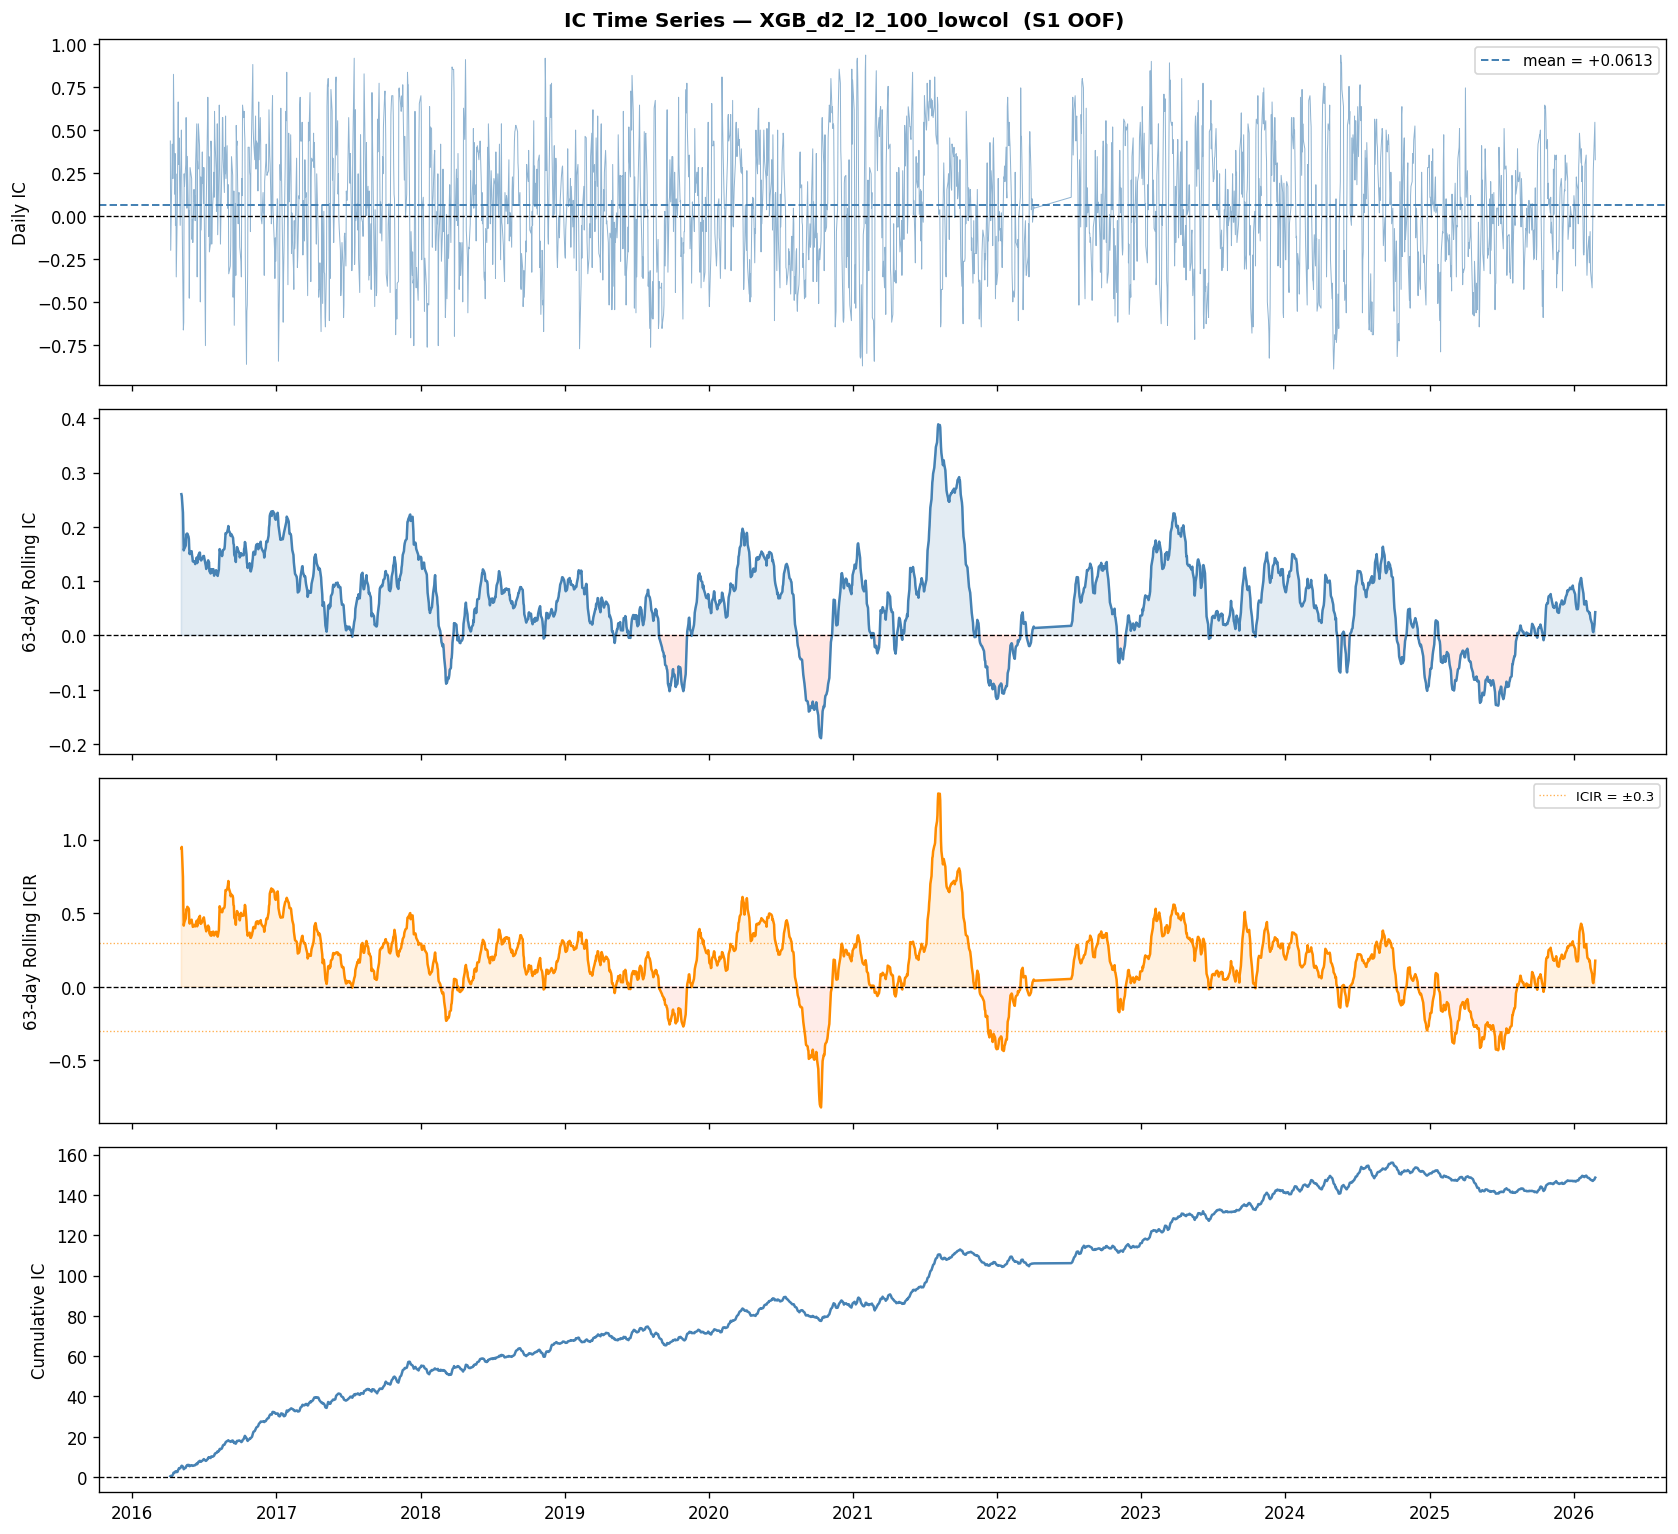

In [32]:
ic = compute_ic_series(pred)
ic_roll  = ic.rolling(63, min_periods=21).mean()
ic_std   = ic.rolling(63, min_periods=21).std()
ic_icir  = ic_roll / ic_std                        # rolling ICIR
ic_cum   = ic.cumsum()

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)
fig.suptitle(f'IC Time Series — {spec["model_name"]}  (S1 OOF)', fontsize=12, fontweight='bold')

# ── Panel 1: daily IC ────────────────────────────────────────────────────────
axes[0].plot(ic.index, ic.values, lw=0.6, color='steelblue', alpha=0.6)
axes[0].axhline(0,         color='black',     lw=0.8, ls='--')
axes[0].axhline(ic.mean(), color='steelblue', lw=1.2, ls='--',
                label=f'mean = {ic.mean():+.4f}')
axes[0].set_ylabel('Daily IC')
axes[0].legend(fontsize=9)

# ── Panel 2: 63-day rolling mean IC ──────────────────────────────────────────
axes[1].plot(ic_roll.index, ic_roll.values, lw=1.5, color='steelblue')
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].fill_between(ic_roll.index, 0, ic_roll.values,
                     where=ic_roll.values > 0, alpha=0.15, color='steelblue')
axes[1].fill_between(ic_roll.index, 0, ic_roll.values,
                     where=ic_roll.values < 0, alpha=0.15, color='tomato')
axes[1].set_ylabel('63-day Rolling IC')

# ── Panel 3: 63-day rolling ICIR ─────────────────────────────────────────────
axes[2].plot(ic_icir.index, ic_icir.values, lw=1.5, color='darkorange')
axes[2].axhline(0,    color='black',      lw=0.8, ls='--')
axes[2].axhline(0.3,  color='darkorange', lw=0.8, ls=':', alpha=0.7, label='ICIR = ±0.3')
axes[2].axhline(-0.3, color='darkorange', lw=0.8, ls=':', alpha=0.7)
axes[2].fill_between(ic_icir.index, 0, ic_icir.values,
                     where=ic_icir.values > 0, alpha=0.12, color='darkorange')
axes[2].fill_between(ic_icir.index, 0, ic_icir.values,
                     where=ic_icir.values < 0, alpha=0.12, color='tomato')
axes[2].set_ylabel('63-day Rolling ICIR')
axes[2].legend(fontsize=8)

# ── Panel 4: cumulative IC ───────────────────────────────────────────────────
axes[3].plot(ic_cum.index, ic_cum.values, lw=1.5, color='steelblue')
axes[3].axhline(0, color='black', lw=0.8, ls='--')
axes[3].set_ylabel('Cumulative IC')
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

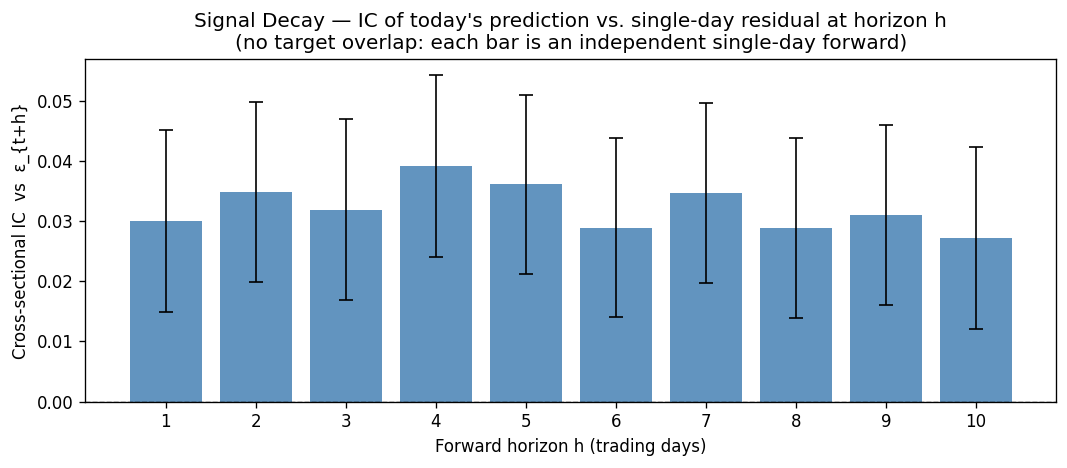

                 IC  IC_sem
horizon_days               
1            0.0300  0.0077
2            0.0348  0.0076
3            0.0319  0.0077
4            0.0391  0.0077
5            0.0361  0.0076
6            0.0289  0.0076
7            0.0347  0.0076
8            0.0288  0.0076
9            0.0310  0.0076
10           0.0272  0.0077


In [33]:
# ── Signal decay: IC(y_pred_t, eps_{t+h}) for h = 1 … 10 ────────────────────
# Correct approach: correlate today's prediction against the SINGLE-DAY residual
# at horizon h (not the cumulative 5-day target, which overlaps and inflates IC).
# Uses eps from df_full_f — the raw daily PCA residual.
#
# Interpretation: if IC drops sharply at h=2 vs h=1, signal is very short-lived.
# If IC is flat, signal persists and a weekly rebalance is fine.

pred_wide = pred['y_pred'].unstack(level='maturity')

# Build single-day forward residuals from df_full_f
eps_wide = (df_full_f['eps']
            .unstack(level='maturity')
            .reindex(pred_wide.index))   # align to OOF dates

decay_rows = []
for h in range(1, 11):
    eps_fwd = eps_wide.shift(-h)   # eps_{t+h}: forward-shift by h days

    ic_dates = []
    for date in pred_wide.index:
        if date not in eps_fwd.index:
            continue
        yp  = pred_wide.loc[date].dropna()
        eps = eps_fwd.loc[date].dropna()
        common = yp.index.intersection(eps.index)
        if len(common) < 4:
            continue
        r, _ = stats.spearmanr(yp[common], eps[common])
        ic_dates.append(r)

    decay_rows.append({
        'horizon_days': h,
        'IC':           np.nanmean(ic_dates),
        'IC_sem':       np.nanstd(ic_dates) / np.sqrt(len(ic_dates)),
    })

decay_df = pd.DataFrame(decay_rows).set_index('horizon_days')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(decay_df.index, decay_df['IC'],
       yerr=decay_df['IC_sem'] * 1.96, capsize=4, error_kw={'lw': 1},
       color=['steelblue' if v > 0 else 'tomato' for v in decay_df['IC']],
       alpha=0.85)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Forward horizon h (trading days)')
ax.set_ylabel('Cross-sectional IC  vs  ε_{t+h}')
ax.set_title('Signal Decay — IC of today\'s prediction vs. single-day residual at horizon h\n'
             '(no target overlap: each bar is an independent single-day forward)')
ax.set_xticks(decay_df.index)
plt.tight_layout()
plt.show()

print(decay_df.round(4).to_string())

The signal is persistent enough that a multi-day holding / weekly rebalance may make sense.

Since all bars are clearly above zero, the signal appears statistically positive at each horizon.
It says your signal ranks future residual returns well. You still need to check transaction costs, turnover, raw tradable returns, and whether a long-short portfolio built from the signal actually performs

In [34]:
# IC against the actual 5-day cumulative residual target
target_wide = pred["y_true"].unstack("maturity")
pred_wide = pred["y_pred"].unstack("maturity")

ic_dates = []

for date in pred_wide.index:
    yp = pred_wide.loc[date].dropna()
    yt = target_wide.loc[date].dropna()

    common = yp.index.intersection(yt.index)
    if len(common) < 4:
        continue

    r, _ = stats.spearmanr(yp[common], yt[common])
    ic_dates.append(r)

print("IC vs actual model target:", np.nanmean(ic_dates))

IC vs actual model target: 0.061263067154556476


## 7. Feature Importance (MDI + MDA)

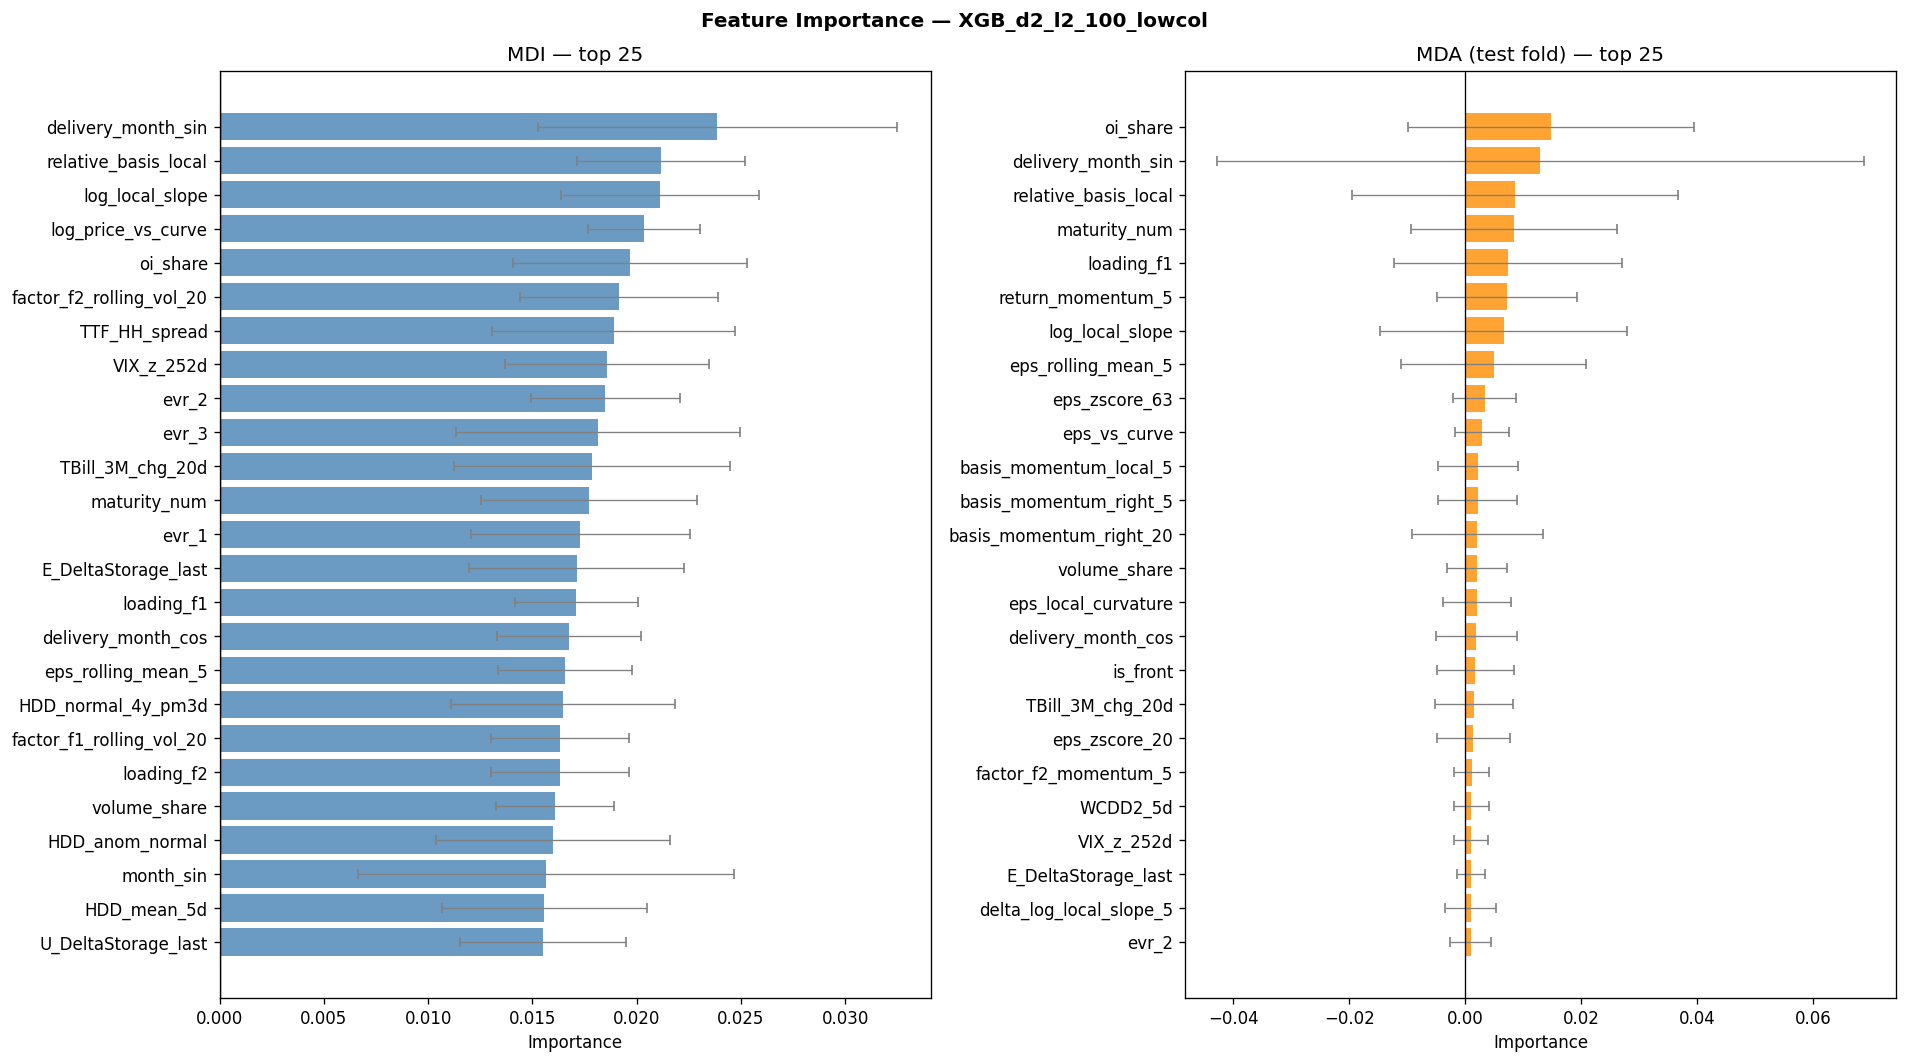

In [36]:
fi = result['feature_importance']
TOP_N = 25

mdi = (fi[fi['type'] == 'MDI']
       .groupby('feature')['importance']
       .agg(['mean', 'std'])
       .sort_values('mean', ascending=False)
       .head(TOP_N)
       .sort_values('mean'))

mda = (fi[fi['type'] == 'MDA']
       .groupby('feature')['importance']
       .agg(['mean', 'std'])
       .sort_values('mean', ascending=False)
       .head(TOP_N)
       .sort_values('mean'))

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
fig.suptitle(f'Feature Importance — {spec["model_name"]}', fontsize=12, fontweight='bold')

for ax, df_fi, title, color in [
    (axes[0], mdi, f'MDI — top {TOP_N}', 'steelblue'),
    (axes[1], mda, f'MDA (test fold) — top {TOP_N}', 'darkorange'),
]:
    ax.barh(df_fi.index, df_fi['mean'], xerr=df_fi['std'],
            color=color, alpha=0.8, capsize=3, ecolor='grey', error_kw={'lw': 0.8})
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(title)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [37]:
# ── MDA table: features with negative importance are worth dropping ───────────
mda_full = (fi[fi['type'] == 'MDA']
            .groupby('feature')['importance']
            .agg(['mean', 'std'])
            .sort_values('mean', ascending=False))
mda_full.columns = ['MDA_mean', 'MDA_std']
print('Bottom 15 MDA features (consider dropping):')
print(mda_full.tail(15).to_string())

Bottom 15 MDA features (consider dropping):
                          MDA_mean  MDA_std
feature                                    
is_summer_peak              0.0000   0.0000
EStorage_x_D1              -0.0000   0.0001
factor_f2_rolling_vol_20   -0.0000   0.0038
HDD_dec                    -0.0001   0.0003
CDD_inc                    -0.0001   0.0003
E_HDD                      -0.0001   0.0015
is_withdrawal_season       -0.0001   0.0003
WTI_ret_5d                 -0.0001   0.0044
SP500_ret_1d               -0.0001   0.0014
loading_f2                 -0.0004   0.0067
factor_f3_rolling_vol_20   -0.0005   0.0026
WHDD2_5d                   -0.0005   0.0013
factor_f3_zscore_20        -0.0006   0.0017
is_winter_delivery         -0.0013   0.0114
log_price_vs_curve         -0.0019   0.0299


Feature group MDA contribution (sum over group, normalized):
                  MDA_sum  n_features  MDA_pct
group                                         
Curve shape       -0.0184           9 -37.2513
Calendar          -0.0069          13 -13.9667
Residual (PCA)    -0.0069           5 -13.9428
Factor loadings   -0.0051           3 -10.2766
Microstructure    -0.0032           3  -6.4626
Weather           -0.0028          22  -5.7291
Factor dynamics   -0.0024           9  -4.9240
Macro             -0.0021           6  -4.1825
Storage            0.0001           9   0.2981
Factor structure   0.0015           3   2.9662


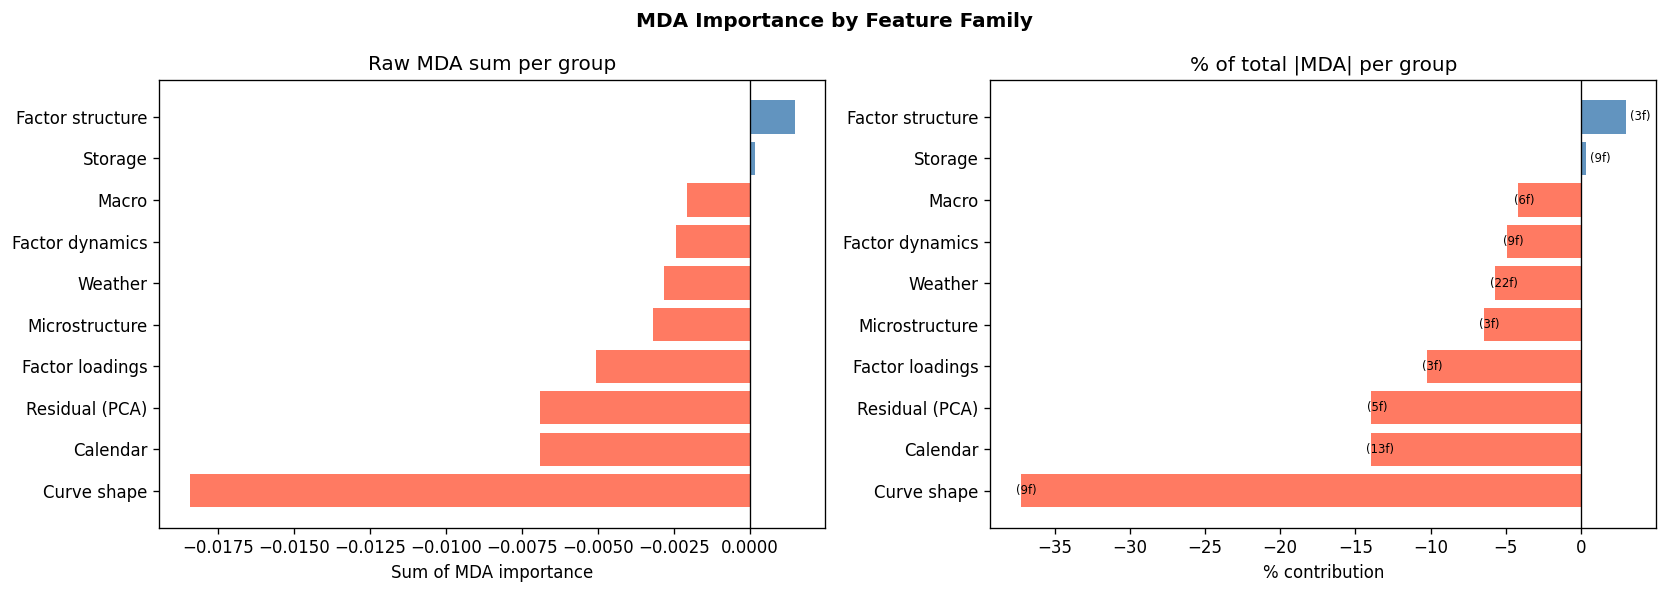

In [69]:
# ── MDA importance by feature family ─────────────────────────────────────────
# Sum MDA across all features in each group, then normalize by total abs sum.
# Shows which part of the feature space drives signal vs. noise.

FEATURE_GROUPS = {
    # ── Family A ─────────────────────────────────────────────────────────────
    'Residual (PCA)': [
        'eps', 'eps_lag_1', 'eps_lag_5', 'eps_rolling_mean_5', 'eps_rolling_mean_20',
        'eps_rolling_std_20', 'eps_rolling_std_63', 'eps_zscore_20', 'eps_zscore_63',
        'eps_momentum_5', 'eps_momentum_20', 'cum_dislocation_5', 'cum_dislocation_20',
        'eps_cum5_zscore', 'eps_vs_curve', 'eps_local_curvature', 'eps_curve_std',
    ],
    'Microstructure': [
        'volume', 'oi', 'bid', 'ask', 'vwap',
        'bid_ask_spread', 'bid_ask_spread_pct', 'vwap_close_diff',
        'volume_share', 'oi_share', 'oi_change',
    ],
    'Factor loadings': [
        'loading_f1', 'loading_f2', 'loading_f3', 'idio_vol_loading',
    ],
    'Curve shape': [
        'log_price_vs_curve', 'log_local_slope', 'relative_basis_local',
        'delta_relative_basis_5', 'delta_relative_basis_20',
        'return_momentum_5', 'return_momentum_20',
        'basis_momentum_right_5', 'basis_momentum_right_20',
        'basis_momentum_local_5', 'basis_momentum_local_20',
        'delta_log_local_slope_5', 'delta_log_local_slope_20',
        'curve_log_level', 'curve_log_slope_1_12', 'curve_log_slope_1_6', 'curve_log_slope_6_12',

    ],
    # ── Family B ─────────────────────────────────────────────────────────────
    'Factor dynamics': [
        'factor_f1', 'factor_f1_lag_1', 'factor_f1_lag_5',
        'factor_f1_rolling_vol_20', 'factor_f1_momentum_5', 'factor_f1_zscore_20',
        'factor_f2', 'factor_f2_lag_1', 'factor_f2_lag_5',
        'factor_f2_rolling_vol_20', 'factor_f2_momentum_5', 'factor_f2_zscore_20',
        'factor_f3', 'factor_f3_lag_1', 'factor_f3_lag_5',
        'factor_f3_rolling_vol_20', 'factor_f3_momentum_5', 'factor_f3_zscore_20',
    ],
    'Factor structure': [
        'evr_1', 'evr_2', 'evr_3', 'cum_evr_3',
        'eigenvalue_1', 'eigenvalue_2', 'eigenvalue_3',
        'cos_sim_f1', 'cos_sim_f2', 'cos_sim_f3',
        'market_volume', 'market_oi',
    ],

    'Weather': [
        'HDD', 'CDD', 'HDD2', 'CDD2', 'HDD_inc', 'HDD_dec', 'CDD_inc', 'CDD_dec',
        'HDD_sum_5d', 'CDD_sum_5d', 'HDD_mean_5d', 'CDD_mean_5d',
        'HDD_var_5d', 'CDD_var_5d', 'HDD_sum_10d', 'CDD_sum_10d',
        'HDD_var_10d', 'CDD_var_10d',
        'HDD_normal_4y_pm3d', 'CDD_normal_4y_pm3d', 'HDD2_normal_4y_pm3d', 'CDD2_normal_4y_pm3d',
        'HDD_anom_normal', 'CDD_anom_normal', 'HDD2_anom_normal', 'CDD2_anom_normal',
        'E_HDD', 'U_HDD', 'Z_HDD', 'E_CDD', 'U_CDD', 'Z_CDD',
        'E_HDD2', 'U_HDD2', 'Z_HDD2', 'E_CDD2', 'U_CDD2', 'Z_CDD2',
        'WHDD_5d', 'WCDD_5d', 'WHDD2_5d', 'WCDD2_5d',
    ],
    'Storage': [
        'Storage', 'DeltaStorage_last', 'is_storage_announcement_day',
        'days_since_storage_announcement',
        'E_DeltaStorage_last', 'U_DeltaStorage_last', 'Z_DeltaStorage_last',
        'UStorage_x_D0', 'UStorage_x_D1', 'UStorage_x_D2', 'UStorage_x_D3',
        'EStorage_x_D0', 'EStorage_x_D1', 'EStorage_x_D2', 'EStorage_x_D3',
    ],
    'Macro': [
        'HH_spot_ret_1d', 'HH_spot_ret_5d', 'HH_spot_vol_20d',
        'WTI_ret_1d', 'WTI_ret_5d', 'WTI_vol_20d',
        'OVX_z_252d', 'VIX_z_252d', 'TBill_3M_chg_20d',
        'SP500_ret_1d', 'SP500_vol_20d', 'TTF_HH_spread',
    ],
    'Calendar': [
        'month_sin', 'month_cos', 'is_injection_season', 'is_withdrawal_season',
        'is_summer_peak', 'delivery_month_sin', 'delivery_month_cos',
        'is_winter_delivery', 'is_summer_delivery', 'maturity_num',
        'is_front', 'is_belly', 'is_back',
    ],
}

mda_per_feat = (
    fi[fi['type'] == 'MDA']
    .groupby('feature')['importance']
    .mean()
)

# Sum MDA within each group (features absent from the model contribute 0)
group_rows = []
for group, feats in FEATURE_GROUPS.items():
    present  = [f for f in feats if f in mda_per_feat.index]
    raw_sum  = mda_per_feat[present].sum() if present else 0.0
    n_active = len(present)
    group_rows.append({'group': group, 'MDA_sum': raw_sum, 'n_features': n_active})

grp_df = pd.DataFrame(group_rows).set_index('group')
total_abs = grp_df['MDA_sum'].abs().sum()
grp_df['MDA_pct'] = grp_df['MDA_sum'] / total_abs * 100  # % of total absolute MDA
grp_df = grp_df.sort_values('MDA_sum', ascending=True)

print('Feature group MDA contribution (sum over group, normalized):')
print(grp_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MDA Importance by Feature Family', fontsize=12, fontweight='bold')

colors = ['steelblue' if v >= 0 else 'tomato' for v in grp_df['MDA_sum']]

# Left: raw MDA sum per group
axes[0].barh(grp_df.index, grp_df['MDA_sum'], color=colors, alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Raw MDA sum per group')
axes[0].set_xlabel('Sum of MDA importance')

# Right: % of total absolute MDA (positive = signal, negative = noise)
pct_colors = ['steelblue' if v >= 0 else 'tomato' for v in grp_df['MDA_pct']]
axes[1].barh(grp_df.index, grp_df['MDA_pct'], color=pct_colors, alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('% of total |MDA| per group')
axes[1].set_xlabel('% contribution')
for i, (idx, row) in enumerate(grp_df.iterrows()):
    axes[1].text(row['MDA_pct'] + 0.3 * np.sign(row['MDA_pct']),
                 i, f"({row['n_features']:.0f}f)", va='center', fontsize=7)

plt.tight_layout()
plt.show()

Feature group MDI contribution (sum over group, normalized):
                  MDI_sum  n_features  MDI_pct
group                                         
Factor structure   0.0470           3   4.7017
Microstructure     0.0564           3   5.6403
Factor loadings    0.0577           3   5.7666
Storage            0.0687           9   6.8698
Residual (PCA)     0.0731           5   7.3058
Macro              0.0861           6   8.6084
Factor dynamics    0.1107           9  11.0696
Curve shape        0.1484           9  14.8419
Calendar           0.1647          13  16.4655
Weather            0.1873          22  18.7303


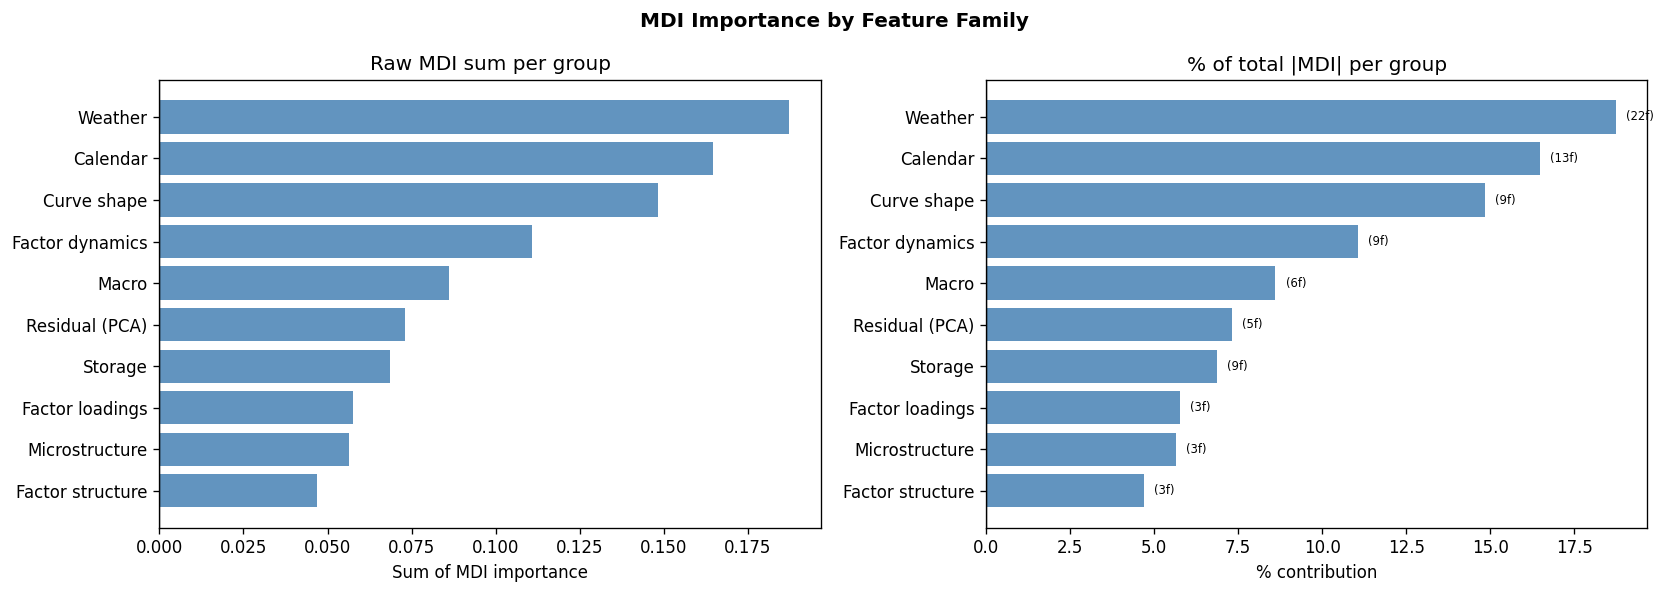

In [70]:
# ── MDI importance by feature family ─────────────────────────────────────────
# Sum MDI across all features in each group, then normalize by total abs sum.
# Shows which part of the feature space drives signal vs. noise.


MDI_per_feat = (
    fi[fi['type'] == 'MDI']
    .groupby('feature')['importance']
    .mean()
)

# Sum MDI within each group (features absent from the model contribute 0)
group_rows = []
for group, feats in FEATURE_GROUPS.items():
    present  = [f for f in feats if f in MDI_per_feat.index]
    raw_sum  = MDI_per_feat[present].sum() if present else 0.0
    n_active = len(present)
    group_rows.append({'group': group, 'MDI_sum': raw_sum, 'n_features': n_active})

grp_df = pd.DataFrame(group_rows).set_index('group')
total_abs = grp_df['MDI_sum'].abs().sum()
grp_df['MDI_pct'] = grp_df['MDI_sum'] / total_abs * 100  # % of total absolute MDI
grp_df = grp_df.sort_values('MDI_sum', ascending=True)

print('Feature group MDI contribution (sum over group, normalized):')
print(grp_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MDI Importance by Feature Family', fontsize=12, fontweight='bold')

colors = ['steelblue' if v >= 0 else 'tomato' for v in grp_df['MDI_sum']]

# Left: raw MDI sum per group
axes[0].barh(grp_df.index, grp_df['MDI_sum'], color=colors, alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Raw MDI sum per group')
axes[0].set_xlabel('Sum of MDI importance')

# Right: % of total absolute MDI (positive = signal, negative = noise)
pct_colors = ['steelblue' if v >= 0 else 'tomato' for v in grp_df['MDI_pct']]
axes[1].barh(grp_df.index, grp_df['MDI_pct'], color=pct_colors, alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('% of total |MDI| per group')
axes[1].set_xlabel('% contribution')
for i, (idx, row) in enumerate(grp_df.iterrows()):
    axes[1].text(row['MDI_pct'] + 0.3 * np.sign(row['MDI_pct']),
                 i, f"({row['n_features']:.0f}f)", va='center', fontsize=7)

plt.tight_layout()
plt.show()

In [71]:
fi = results_s2['feature_importance']

Feature group MDA contribution (sum over group, normalized):
                  MDA_sum  n_features  MDA_pct
group                                         
Curve shape       -0.0184           9 -37.2513
Calendar          -0.0069          13 -13.9667
Residual (PCA)    -0.0069           5 -13.9428
Factor loadings   -0.0051           3 -10.2766
Microstructure    -0.0032           3  -6.4626
Weather           -0.0028          22  -5.7291
Factor dynamics   -0.0024           9  -4.9240
Macro             -0.0021           6  -4.1825
Storage            0.0001           9   0.2981
Factor structure   0.0015           3   2.9662


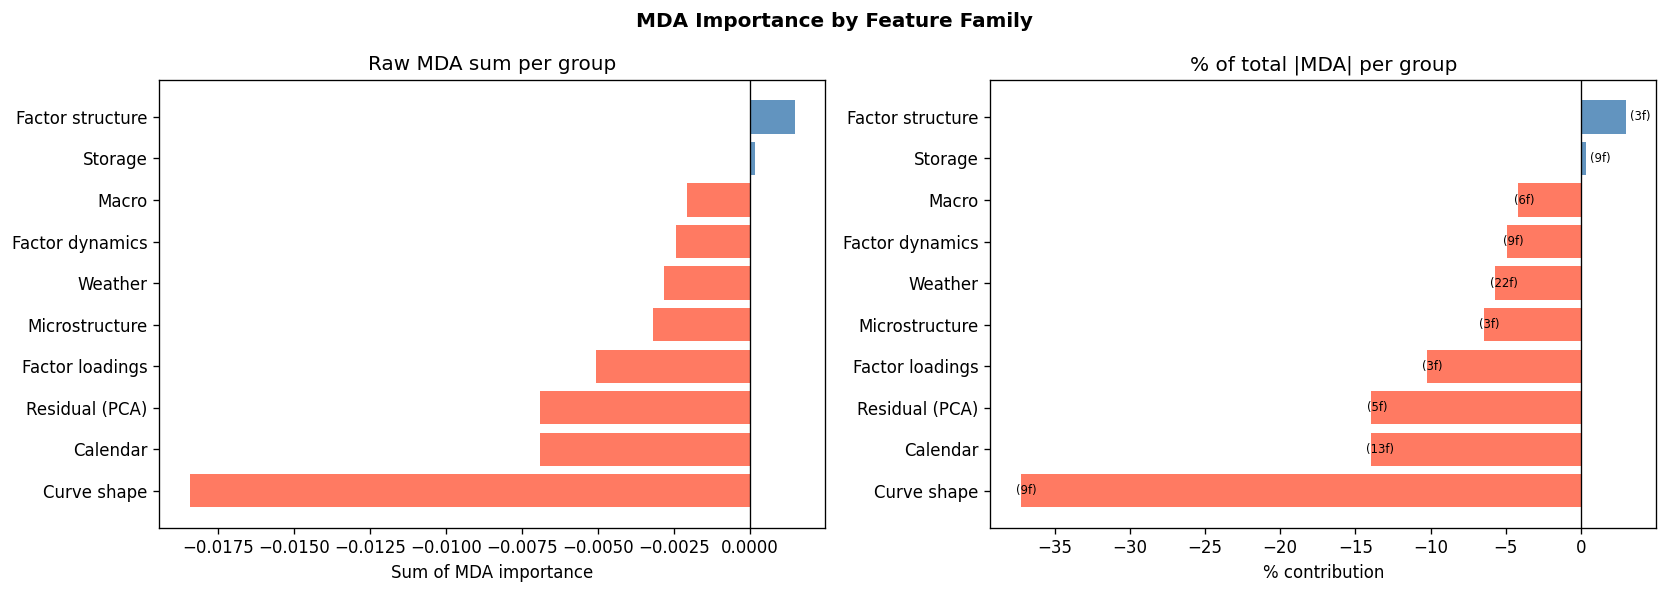

In [72]:
# ── MDA importance by feature family ─────────────────────────────────────────
# Sum MDA across all features in each group, then normalize by total abs sum.
# Shows which part of the feature space drives signal vs. noise.

mda_per_feat = (
    fi[fi['type'] == 'MDA']
    .groupby('feature')['importance']
    .mean()
)

# Sum MDA within each group (features absent from the model contribute 0)
group_rows = []
for group, feats in FEATURE_GROUPS.items():
    present  = [f for f in feats if f in mda_per_feat.index]
    raw_sum  = mda_per_feat[present].sum() if present else 0.0
    n_active = len(present)
    group_rows.append({'group': group, 'MDA_sum': raw_sum, 'n_features': n_active})

grp_df = pd.DataFrame(group_rows).set_index('group')
total_abs = grp_df['MDA_sum'].abs().sum()
grp_df['MDA_pct'] = grp_df['MDA_sum'] / total_abs * 100  # % of total absolute MDA
grp_df = grp_df.sort_values('MDA_sum', ascending=True)

print('Feature group MDA contribution (sum over group, normalized):')
print(grp_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MDA Importance by Feature Family', fontsize=12, fontweight='bold')

colors = ['steelblue' if v >= 0 else 'tomato' for v in grp_df['MDA_sum']]

# Left: raw MDA sum per group
axes[0].barh(grp_df.index, grp_df['MDA_sum'], color=colors, alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Raw MDA sum per group')
axes[0].set_xlabel('Sum of MDA importance')

# Right: % of total absolute MDA (positive = signal, negative = noise)
pct_colors = ['steelblue' if v >= 0 else 'tomato' for v in grp_df['MDA_pct']]
axes[1].barh(grp_df.index, grp_df['MDA_pct'], color=pct_colors, alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('% of total |MDA| per group')
axes[1].set_xlabel('% contribution')
for i, (idx, row) in enumerate(grp_df.iterrows()):
    axes[1].text(row['MDA_pct'] + 0.3 * np.sign(row['MDA_pct']),
                 i, f"({row['n_features']:.0f}f)", va='center', fontsize=7)

plt.tight_layout()
plt.show()

Feature group MDI contribution (sum over group, normalized):
                  MDI_sum  n_features  MDI_pct
group                                         
Factor structure   0.0470           3   4.7017
Microstructure     0.0564           3   5.6403
Factor loadings    0.0577           3   5.7666
Storage            0.0687           9   6.8698
Residual (PCA)     0.0731           5   7.3058
Macro              0.0861           6   8.6084
Factor dynamics    0.1107           9  11.0696
Curve shape        0.1484           9  14.8419
Calendar           0.1647          13  16.4655
Weather            0.1873          22  18.7303


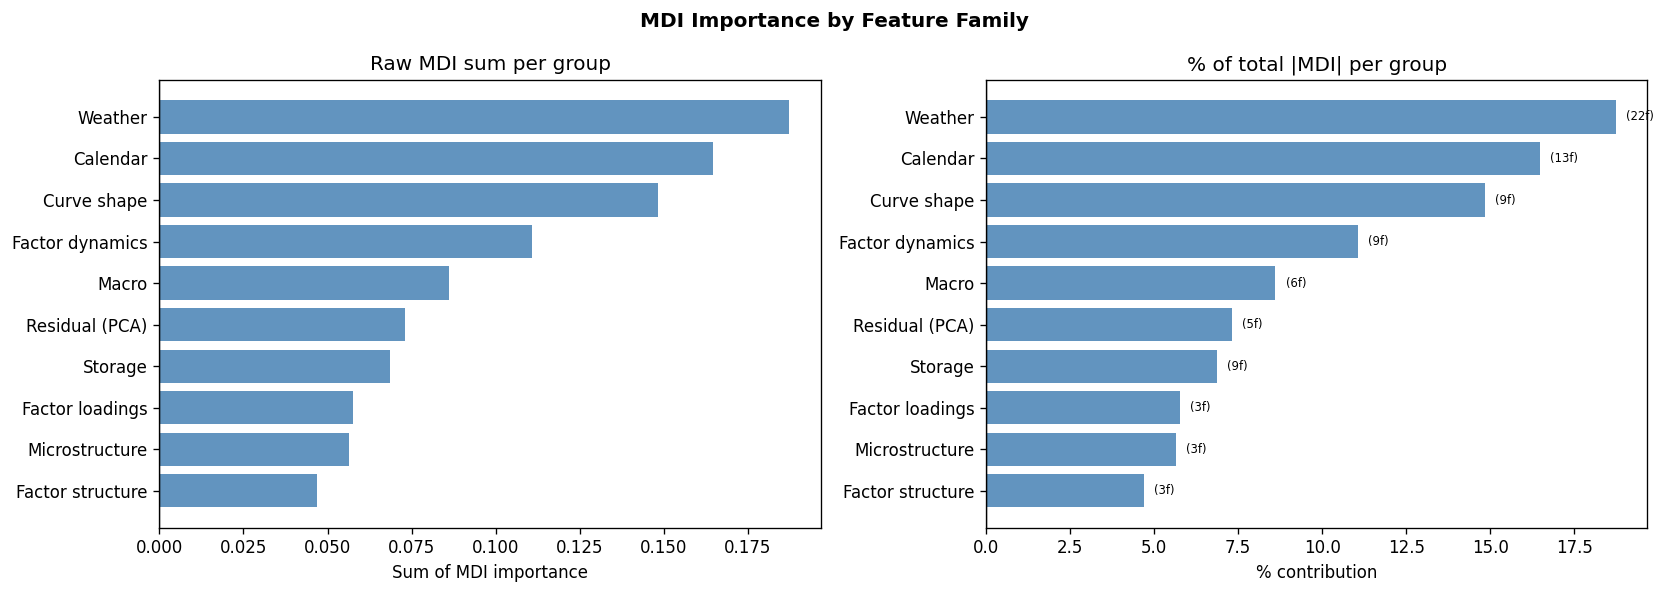

In [73]:
# ── MDI importance by feature family ─────────────────────────────────────────
# Sum MDI across all features in each group, then normalize by total abs sum.
# Shows which part of the feature space drives signal vs. noise.

MDI_per_feat = (
    fi[fi['type'] == 'MDI']
    .groupby('feature')['importance']
    .mean()
)

# Sum MDI within each group (features absent from the model contribute 0)
group_rows = []
for group, feats in FEATURE_GROUPS.items():
    present  = [f for f in feats if f in MDI_per_feat.index]
    raw_sum  = MDI_per_feat[present].sum() if present else 0.0
    n_active = len(present)
    group_rows.append({'group': group, 'MDI_sum': raw_sum, 'n_features': n_active})

grp_df = pd.DataFrame(group_rows).set_index('group')
total_abs = grp_df['MDI_sum'].abs().sum()
grp_df['MDI_pct'] = grp_df['MDI_sum'] / total_abs * 100  # % of total absolute MDI
grp_df = grp_df.sort_values('MDI_sum', ascending=True)

print('Feature group MDI contribution (sum over group, normalized):')
print(grp_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MDI Importance by Feature Family', fontsize=12, fontweight='bold')

colors = ['steelblue' if v >= 0 else 'tomato' for v in grp_df['MDI_sum']]

# Left: raw MDI sum per group
axes[0].barh(grp_df.index, grp_df['MDI_sum'], color=colors, alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Raw MDI sum per group')
axes[0].set_xlabel('Sum of MDI importance')

# Right: % of total absolute MDI (positive = signal, negative = noise)
pct_colors = ['steelblue' if v >= 0 else 'tomato' for v in grp_df['MDI_pct']]
axes[1].barh(grp_df.index, grp_df['MDI_pct'], color=pct_colors, alpha=0.85)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('% of total |MDI| per group')
axes[1].set_xlabel('% contribution')
for i, (idx, row) in enumerate(grp_df.iterrows()):
    axes[1].text(row['MDI_pct'] + 0.3 * np.sign(row['MDI_pct']),
                 i, f"({row['n_features']:.0f}f)", va='center', fontsize=7)

plt.tight_layout()
plt.show()

## 8. Analysis by Maturity

IC decomposed by tenor: **front** (M1–M4), **belly** (M5–M8), **back** (M9–M12).

In [44]:
preds = pred.copy()

# ── Time-series IC and MSE per maturity ───────────────────────────────────────
# Time-series IC: Spearman(y_pred_{M_i,t}, y_true_{M_i,t}) across all OOF dates
# for maturity M_i separately. Different from the cross-sectional IC (which ranks
# maturities against each other on a given day) — this measures how well the
# signal tracks each maturity's own realized residual through time.
mat_rows = []
for mat, grp in preds.groupby(level='maturity'):
    yt = grp['y_true'].dropna()
    yp = grp['y_pred'].loc[yt.index]
    if len(yt) < 10:
        continue
    r, pval = stats.spearmanr(yp, yt)
    mse = float(np.mean((yp - yt) ** 2))
    mat_rows.append({
        'maturity': mat,
        'ts_IC':    r,
        'p_value':  pval,
        'MSE':      mse,
        'N':        len(yt),
    })

mat_df = (pd.DataFrame(mat_rows)
          .set_index('maturity')
          .reindex([f'M{i}' for i in range(1, 13)]))
print('Per-maturity time-series IC and MSE:')
print(mat_df.round(4).to_string())

Per-maturity time-series IC and MSE:
          ts_IC  p_value    MSE         N
maturity                                 
M1       0.0467   0.0215 2.2886 2425.0000
M2       0.0614   0.0025 2.0354 2425.0000
M3       0.0446   0.0281 2.5645 2425.0000
M4       0.0190   0.3509 2.2362 2425.0000
M5       0.0238   0.2417 2.1468 2425.0000
M6       0.0551   0.0066 2.4397 2425.0000
M7       0.0570   0.0050 2.2228 2425.0000
M8       0.0383   0.0592 1.9008 2425.0000
M9       0.0509   0.0122 2.5252 2425.0000
M10      0.0282   0.1653 2.3676 2425.0000
M11      0.0359   0.0771 2.0564 2425.0000
M12         NaN      NaN    NaN       NaN


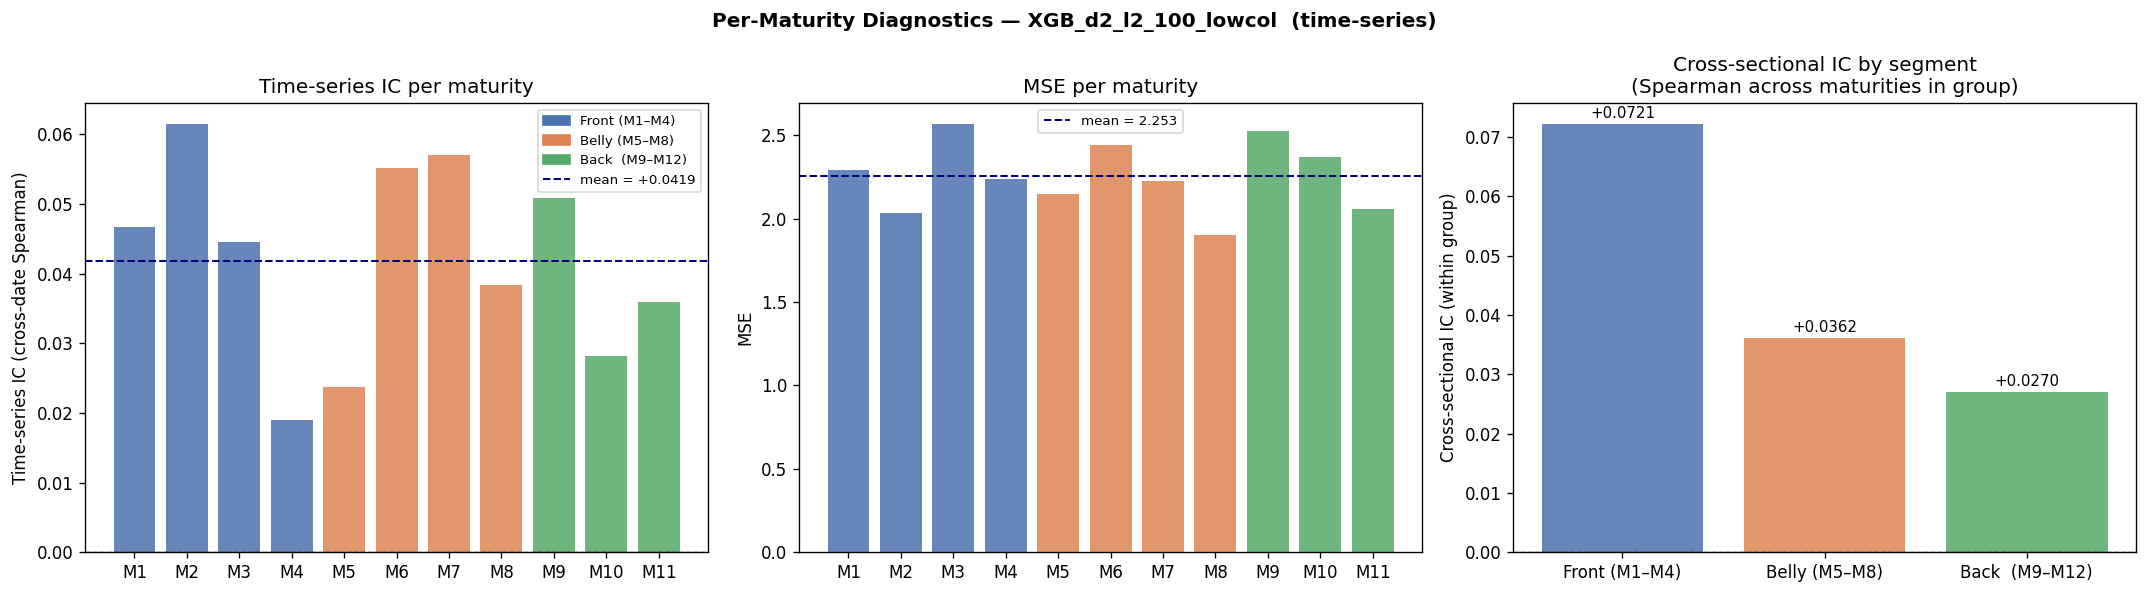

In [45]:
GROUPS = {
    'Front (M1–M4)':  [f'M{i}' for i in range(1, 5)],
    'Belly (M5–M8)':  [f'M{i}' for i in range(5, 9)],
    'Back  (M9–M12)': [f'M{i}' for i in range(9, 13)],
}
GROUP_COLORS = {'Front (M1–M4)': '#4C72B0', 'Belly (M5–M8)': '#DD8452', 'Back  (M9–M12)': '#55A868'}

color_map = {m: c for g, mats in GROUPS.items() for m, c in zip(mats, [GROUP_COLORS[g]] * 4)}
bar_colors = [color_map.get(m, 'grey') for m in mat_df.index]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Per-Maturity Diagnostics — {spec["model_name"]}  (time-series)',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_handles = [Patch(color=GROUP_COLORS[g], label=g) for g in GROUPS]

# ── Left: time-series IC per maturity ────────────────────────────────────────
axes[0].bar(mat_df.index, mat_df['ts_IC'], color=bar_colors, alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].axhline(mat_df['ts_IC'].mean(), color='navy', lw=1.2, ls='--',
                label=f'mean = {mat_df["ts_IC"].mean():+.4f}')
axes[0].set_ylabel('Time-series IC (cross-date Spearman)')
axes[0].set_title('Time-series IC per maturity')
axes[0].legend(handles=legend_handles + [axes[0].lines[-1]], fontsize=8)

# ── Middle: MSE per maturity ──────────────────────────────────────────────────
axes[1].bar(mat_df.index, mat_df['MSE'], color=bar_colors, alpha=0.85)
axes[1].axhline(mat_df['MSE'].mean(), color='navy', lw=1.2, ls='--',
                label=f'mean = {mat_df["MSE"].mean():.3f}')
axes[1].set_ylabel('MSE')
axes[1].set_title('MSE per maturity')
axes[1].legend(fontsize=8)

# ── Right: cross-sectional IC by segment (from compute_ic_series) ─────────────
grp_ic = {}
for g, mats in GROUPS.items():
    grp_preds = preds[preds.index.get_level_values('maturity').isin(mats)]
    grp_ic[g] = compute_ic_series(grp_preds).mean()

gkeys = list(grp_ic.keys())
gvals = [grp_ic[g] for g in gkeys]
axes[2].bar(gkeys, gvals, color=[GROUP_COLORS[g] for g in gkeys], alpha=0.85)
axes[2].axhline(0, color='black', lw=0.8, ls='--')
for i, v in enumerate(gvals):
    axes[2].text(i, v + 0.001 * np.sign(v), f'{v:+.4f}', ha='center', fontsize=9)
axes[2].set_ylabel('Cross-sectional IC (within group)')
axes[2].set_title('Cross-sectional IC by segment\n(Spearman across maturities in group)')

plt.tight_layout()
plt.show()

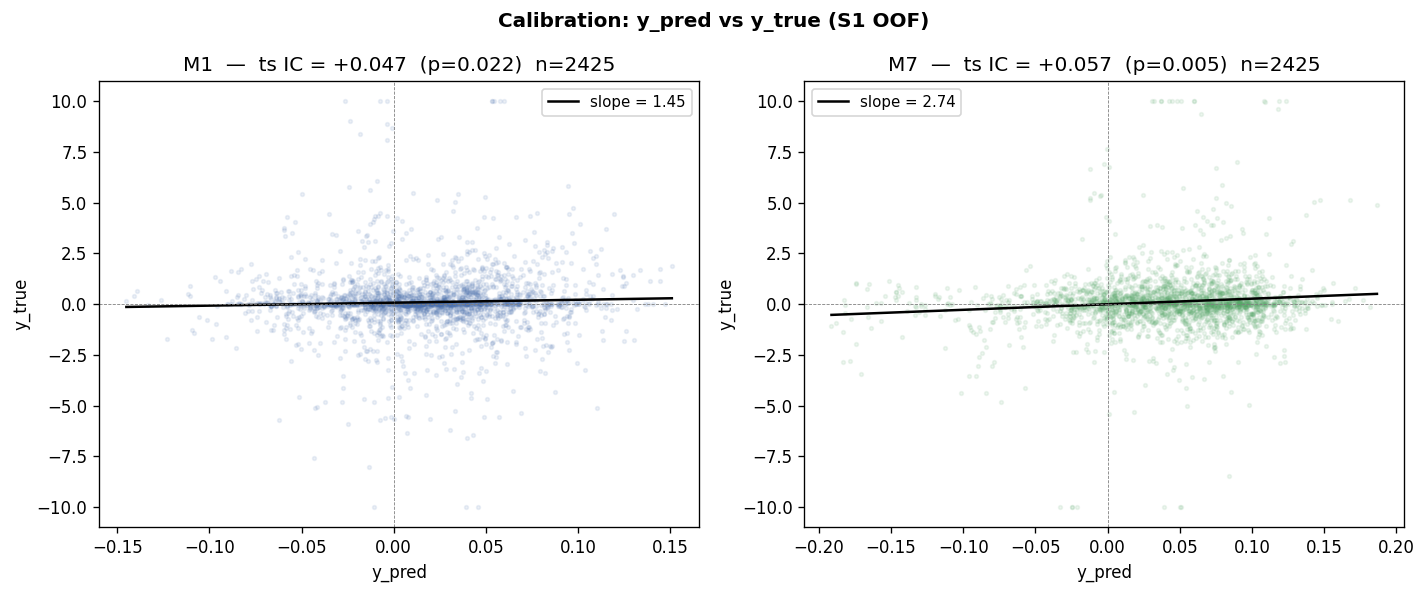

In [46]:
# ── Calibration scatter: y_pred vs y_true for M1 (noise) and M7 (signal) ──────
# Ideal: positive slope + spread concentrated around the line.
# M1 expected near-flat (ts IC ≈ 0); M7 expected visible slope.

SHOW_MATS  = ['M1', 'M7']
MAT_COLORS = {'M1': '#4C72B0', 'M7': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Calibration: y_pred vs y_true (S1 OOF)', fontsize=12, fontweight='bold')

for ax, mat in zip(axes, SHOW_MATS):
    grp     = preds.xs(mat, level='maturity').dropna()
    yp, yt  = grp['y_pred'].values, grp['y_true'].values

    ax.scatter(yp, yt, alpha=0.10, s=5, color=MAT_COLORS[mat])
    m, b = np.polyfit(yp, yt, 1)
    xr   = np.linspace(yp.min(), yp.max(), 100)
    ax.plot(xr, m * xr + b, color='black', lw=1.5, label=f'slope = {m:.2f}')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.axvline(0, color='grey', lw=0.5, ls='--')

    r, pval = stats.spearmanr(yp, yt)
    ax.set_title(f'{mat}  —  ts IC = {r:+.3f}  (p={pval:.3f})  n={len(yt)}')
    ax.set_xlabel('y_pred')
    ax.set_ylabel('y_true')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

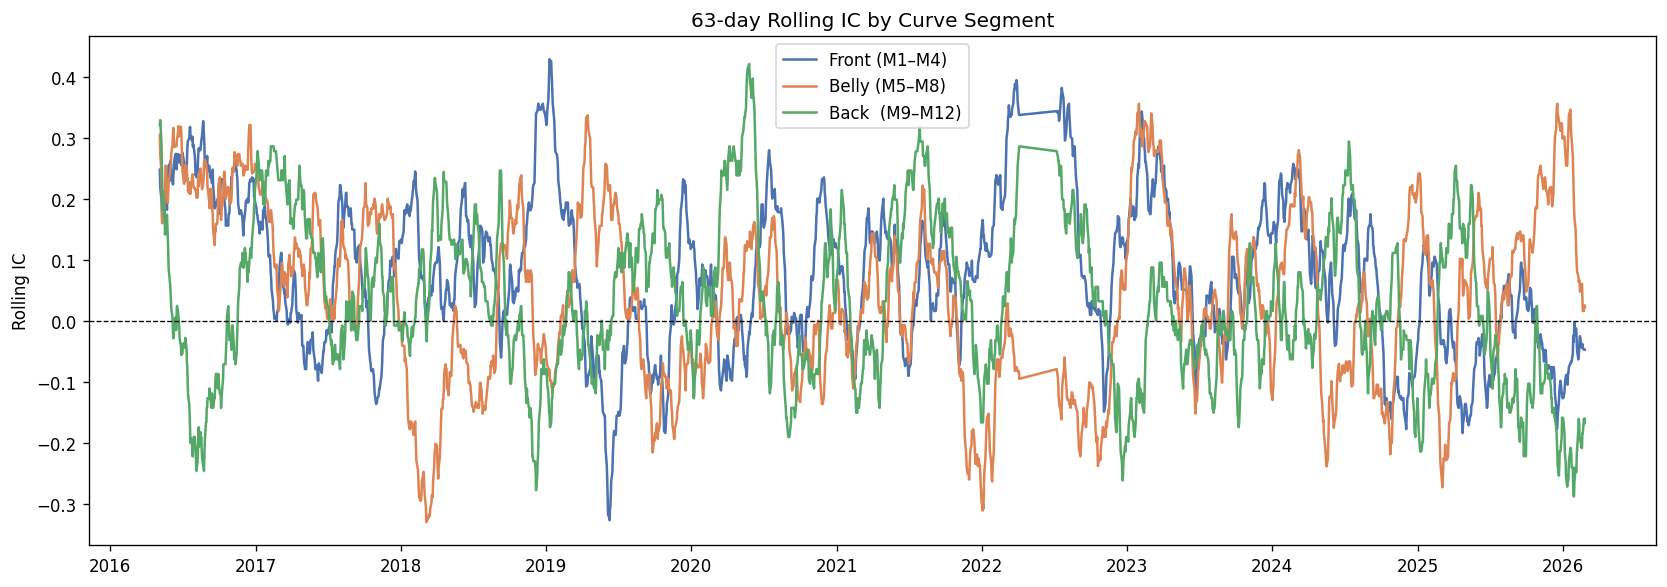

In [47]:
# ── IC time series per maturity group ────────────────────────────────────────
ic_by_group = {}
for g, mats in GROUPS.items():
    grp_preds = preds[preds.index.get_level_values('maturity').isin(mats)]
    ic_by_group[g] = compute_ic_series(grp_preds).rolling(63, min_periods=21).mean()

fig, ax = plt.subplots(figsize=(14, 5))
for g, ic_g in ic_by_group.items():
    ax.plot(ic_g.index, ic_g.values, lw=1.5, label=g, color=GROUP_COLORS[g])
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('63-day Rolling IC by Curve Segment')
ax.set_ylabel('Rolling IC')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

## 9. Event Case Studies (S1 only)

Daily **cross-sectional IC** (Spearman across all 12 maturities on each date) in a ±30-day window around key events.
Measures whether the model correctly ranked maturities against each other during the event — not a time-series IC.

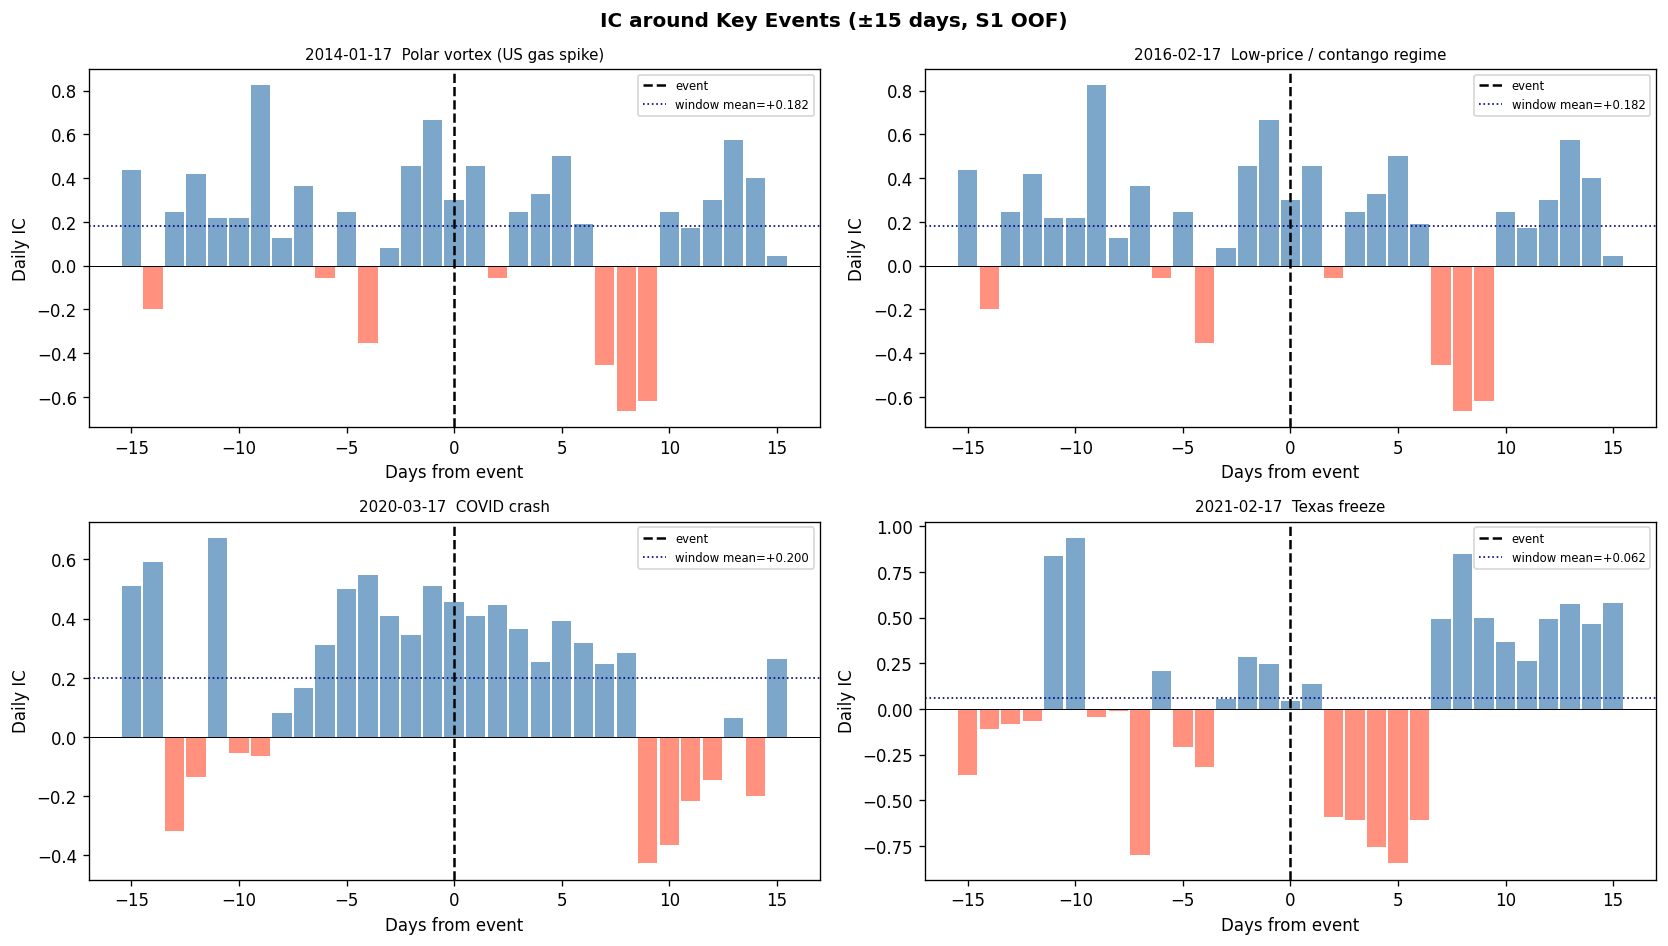

In [48]:
# Only S1 events (≤ 2021-12-31) — S2 events are in the hold-out period
EVENT_DATES = {
    '2014-01-17': 'Polar vortex (US gas spike)',
    '2016-02-17': 'Low-price / contango regime',
    '2020-03-17': 'COVID crash',
    '2021-02-17': 'Texas freeze',
}

WINDOW = 15   # trading days before/after event

ic_all = compute_ic_series(result['predictions'])
ic_dates = ic_all.index

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('IC around Key Events (±15 days, S1 OOF)', fontsize=12, fontweight='bold')

for ax, (date_str, label) in zip(axes.flatten(), EVENT_DATES.items()):
    event_dt = pd.Timestamp(date_str)

    # find closest date in ic_dates
    idx = ic_dates.searchsorted(event_dt)
    idx = min(max(idx, WINDOW), len(ic_dates) - WINDOW - 1)

    window_ic  = ic_all.iloc[idx - WINDOW : idx + WINDOW + 1]
    window_x   = np.arange(-WINDOW, len(window_ic) - WINDOW)
    roll_mean  = window_ic.mean()

    ax.bar(window_x, window_ic.values, color=np.where(window_ic.values > 0, 'steelblue', 'tomato'),
           alpha=0.7, width=0.9)
    ax.axvline(0, color='black', lw=1.5, ls='--', label='event')
    ax.axhline(0, color='black', lw=0.6)
    ax.axhline(roll_mean, color='navy', lw=1.0, ls=':', label=f'window mean={roll_mean:+.3f}')
    ax.set_title(f'{date_str}  {label}', fontsize=9)
    ax.set_xlabel('Days from event')
    ax.set_ylabel('Daily IC')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 10. Conditional IC Analysis

Where does the signal concentrate? Examine IC conditioned on:
- **Volatility regime** — rolling residual vol quintile (`eps_rolling_std_63`)
- **Storage announcement cycle** — `days_since_storage_announcement` (0–5+)
- **Season** — injection (Apr–Oct) vs. withdrawal (Nov–Mar)
- **Storage level** — storage relative to seasonal norm

In [60]:
# ── Build conditioning frame ──────────────────────────────────────────────────
# Daily IC (already computed)
pred = result['predictions']
ic_daily = compute_ic_series(preds).rename('IC')

# Date-level conditioning variables (take first maturity's value — same for all)
date_feats_cols = ['days_since_storage_announcement', 'Storage', 'is_storage_announcement_day']
date_feats_cols = [c for c in date_feats_cols if c in df_full_f.columns]

date_feats = (
    df_full_f[date_feats_cols]
    .reset_index()
    .groupby('date')[date_feats_cols]
    .first()
)

# Maturity-level vol: take cross-maturity mean eps_rolling_std_63 per date
if 'eps_rolling_std_63' in df_full_f.columns:
    vol_mean = (df_full_f['eps_rolling_std_63']
                .groupby(level='date').mean()
                .rename('eps_vol_mean'))
    date_feats = date_feats.join(vol_mean)

cond = ic_daily.to_frame().join(date_feats, how='inner')

# Season label
cond['season'] = cond.index.map(
    lambda d: 'Injection (Apr–Oct)' if 4 <= d.month <= 10 else 'Withdrawal (Nov–Mar)'
)

print(f'Conditioning frame: {cond.shape}')
cond.head()

Conditioning frame: (2425, 6)


,IC,days_since_storage_announcement,Storage,is_storage_announcement_day,eps_vol_mean,season
date,,,,,,
2016-04-07,0.4364,4.0000,2480.0000,0.0000,0.0014,Injection (Apr–Oct)
2016-04-08,-0.2000,0.0000,2477.0000,1.0000,0.0014,Injection (Apr–Oct)
2016-04-11,0.2455,1.0000,2477.0000,0.0000,0.0015,Injection (Apr–Oct)
2016-04-12,0.4182,2.0000,2477.0000,0.0000,0.0015,Injection (Apr–Oct)
2016-04-13,0.2182,3.0000,2477.0000,0.0000,0.0014,Injection (Apr–Oct)


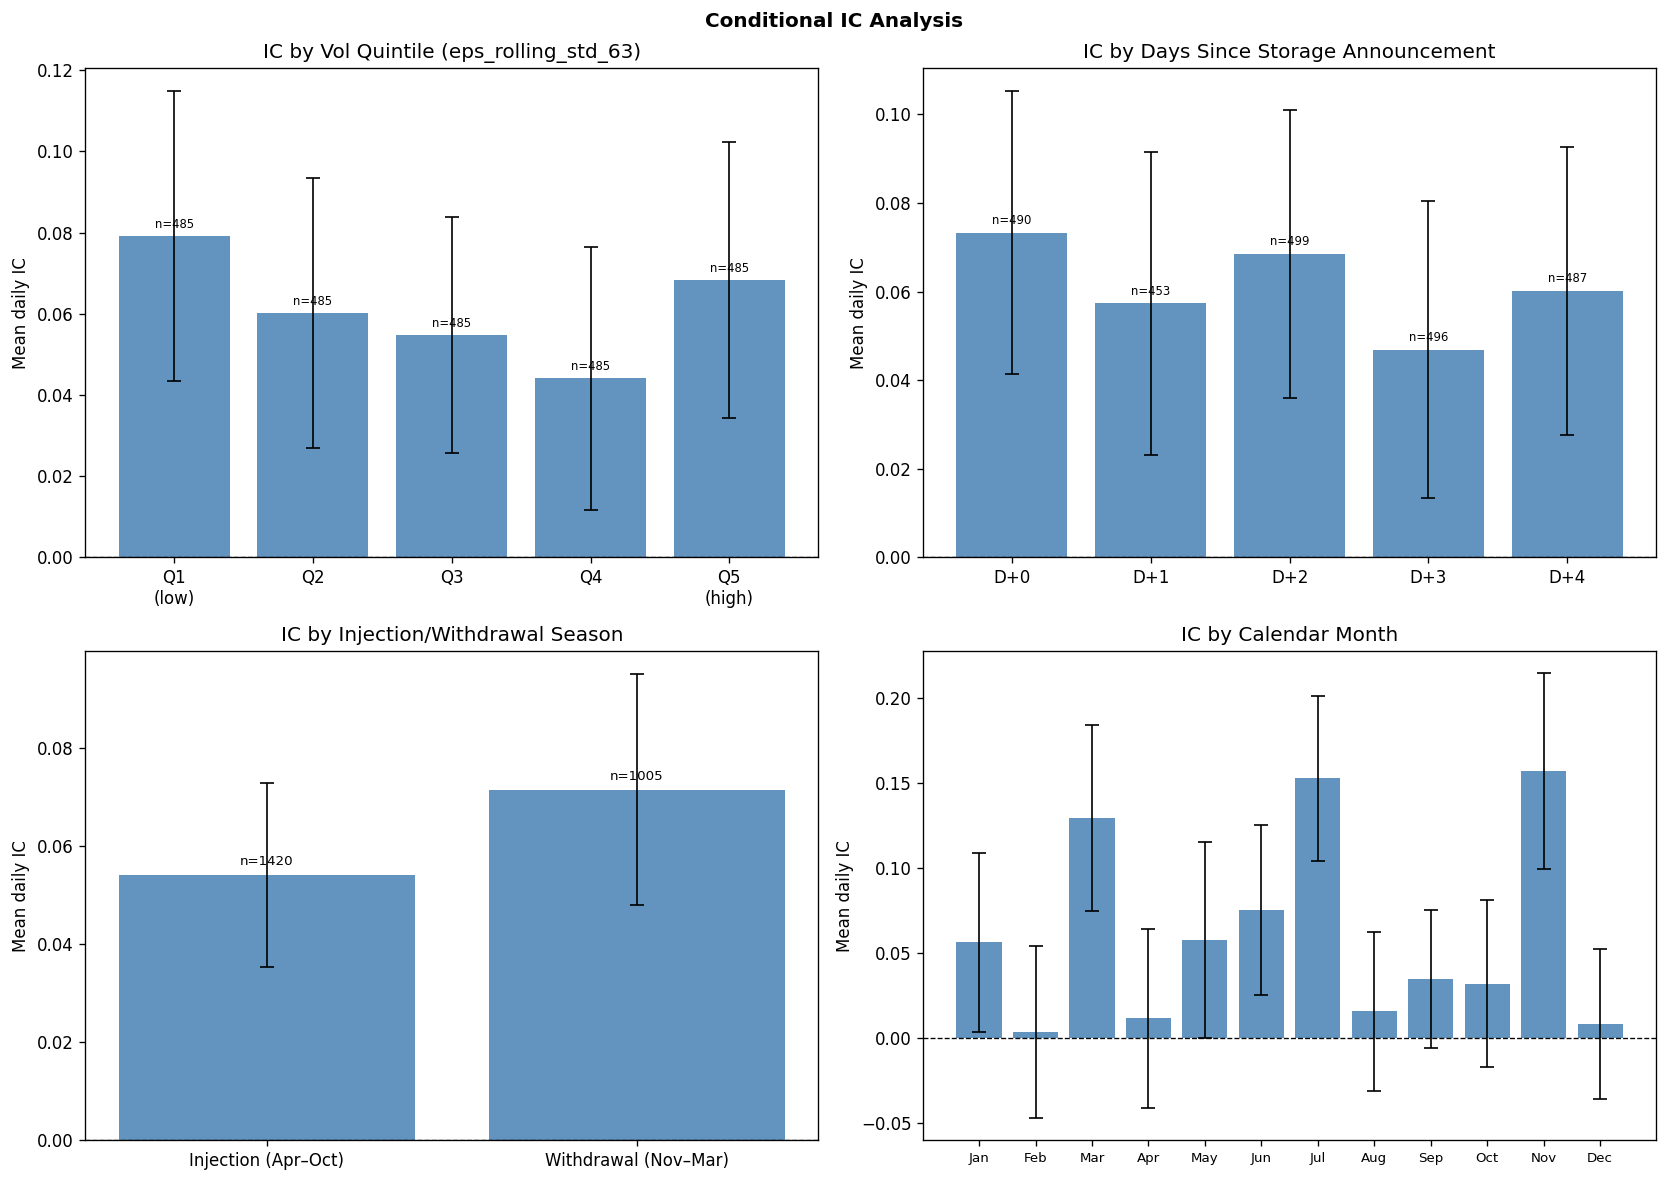

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Conditional IC Analysis', fontsize=12, fontweight='bold')

# ── (a) By volatility quintile ────────────────────────────────────────────────
ax = axes[0, 0]
if 'eps_vol_mean' in cond.columns:
    cond['vol_quintile'] = pd.qcut(cond['eps_vol_mean'], 5,
                                   labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
    vol_ic = cond.groupby('vol_quintile')['IC'].agg(['mean', 'sem', 'count'])
    colors_v = ['steelblue' if v > 0 else 'tomato' for v in vol_ic['mean']]
    ax.bar(vol_ic.index.astype(str), vol_ic['mean'], color=colors_v, alpha=0.85,
           yerr=vol_ic['sem'] * 1.96, capsize=4, error_kw={'lw': 1})
    ax.axhline(0, color='black', lw=0.8, ls='--')
    for i, (idx, row) in enumerate(vol_ic.iterrows()):
        ax.text(i, row['mean'] + 0.002 * np.sign(row['mean']),
                f'n={row["count"]:.0f}', ha='center', fontsize=7)
    ax.set_title('IC by Vol Quintile (eps_rolling_std_63)')
    ax.set_ylabel('Mean daily IC')
else:
    ax.text(0.5, 0.5, 'eps_rolling_std_63 not available', ha='center', va='center',
            transform=ax.transAxes)

# ── (b) By days since storage announcement ────────────────────────────────────
ax = axes[0, 1]
if 'days_since_storage_announcement' in cond.columns:
    cond['days_bucket'] = cond['days_since_storage_announcement'].clip(upper=7).map(
        lambda d: f'D+{int(d)}' if d <= 5 else 'D+6+'
    )
    bucket_order = ['D+0', 'D+1', 'D+2', 'D+3', 'D+4', 'D+5', 'D+6+']
    stor_ic = (cond.groupby('days_bucket')['IC']
               .agg(['mean', 'sem', 'count'])
               .reindex(bucket_order)
               .dropna())
    colors_s = ['steelblue' if v > 0 else 'tomato' for v in stor_ic['mean']]
    ax.bar(stor_ic.index, stor_ic['mean'], color=colors_s, alpha=0.85,
           yerr=stor_ic['sem'] * 1.96, capsize=4, error_kw={'lw': 1})
    ax.axhline(0, color='black', lw=0.8, ls='--')
    for i, (idx, row) in enumerate(stor_ic.iterrows()):
        ax.text(i, row['mean'] + 0.002 * np.sign(row['mean']),
                f'n={row["count"]:.0f}', ha='center', fontsize=7)
    ax.set_title('IC by Days Since Storage Announcement')
    ax.set_ylabel('Mean daily IC')
else:
    ax.text(0.5, 0.5, 'days_since_storage_announcement not available',
            ha='center', va='center', transform=ax.transAxes)

# ── (c) By season ────────────────────────────────────────────────────────────
ax = axes[1, 0]
season_ic = cond.groupby('season')['IC'].agg(['mean', 'sem', 'count'])
colors_sea = ['steelblue' if v > 0 else 'tomato' for v in season_ic['mean']]
ax.bar(season_ic.index, season_ic['mean'], color=colors_sea, alpha=0.85,
       yerr=season_ic['sem'] * 1.96, capsize=4, error_kw={'lw': 1})
ax.axhline(0, color='black', lw=0.8, ls='--')
for i, (idx, row) in enumerate(season_ic.iterrows()):
    ax.text(i, row['mean'] + 0.002 * np.sign(row['mean']),
            f'n={row["count"]:.0f}', ha='center', fontsize=8)
ax.set_title('IC by Injection/Withdrawal Season')
ax.set_ylabel('Mean daily IC')

# ── (d) By calendar month ─────────────────────────────────────────────────────
ax = axes[1, 1]
cond['month'] = cond.index.month
month_ic = cond.groupby('month')['IC'].agg(['mean', 'sem', 'count'])
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors_m = ['steelblue' if v > 0 else 'tomato' for v in month_ic['mean']]
ax.bar(month_ic.index, month_ic['mean'], color=colors_m, alpha=0.85,
       yerr=month_ic['sem'] * 1.96, capsize=4, error_kw={'lw': 1})
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, fontsize=8)
ax.set_title('IC by Calendar Month')
ax.set_ylabel('Mean daily IC')

plt.tight_layout()
plt.show()

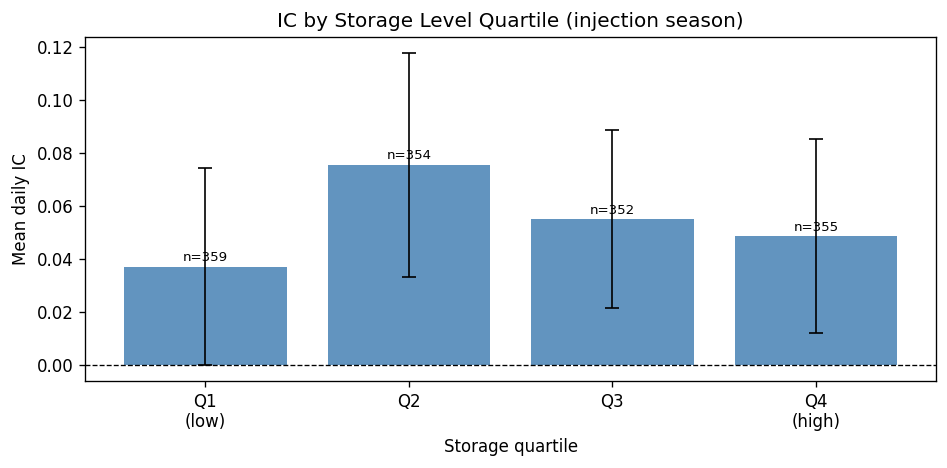

In [62]:
# ── Storage level vs IC (date-level, injection season only) ──────────────────
if 'Storage' in cond.columns:
    cond_inj = cond[cond['season'] == 'Injection (Apr–Oct)'].copy()
    cond_inj['storage_quartile'] = pd.qcut(
        cond_inj['Storage'], 4,
        labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4\n(high)']
    )
    stor_lv = cond_inj.groupby('storage_quartile')['IC'].agg(['mean', 'sem', 'count'])

    fig, ax = plt.subplots(figsize=(8, 4))
    colors_q = ['steelblue' if v > 0 else 'tomato' for v in stor_lv['mean']]
    ax.bar(stor_lv.index.astype(str), stor_lv['mean'], color=colors_q, alpha=0.85,
           yerr=stor_lv['sem'] * 1.96, capsize=4, error_kw={'lw': 1})
    ax.axhline(0, color='black', lw=0.8, ls='--')
    for i, (idx, row) in enumerate(stor_lv.iterrows()):
        ax.text(i, row['mean'] + 0.002 * np.sign(row['mean']),
                f'n={row["count"]:.0f}', ha='center', fontsize=8)
    ax.set_title('IC by Storage Level Quartile (injection season)')
    ax.set_ylabel('Mean daily IC')
    ax.set_xlabel('Storage quartile')
    plt.tight_layout()
    plt.show()

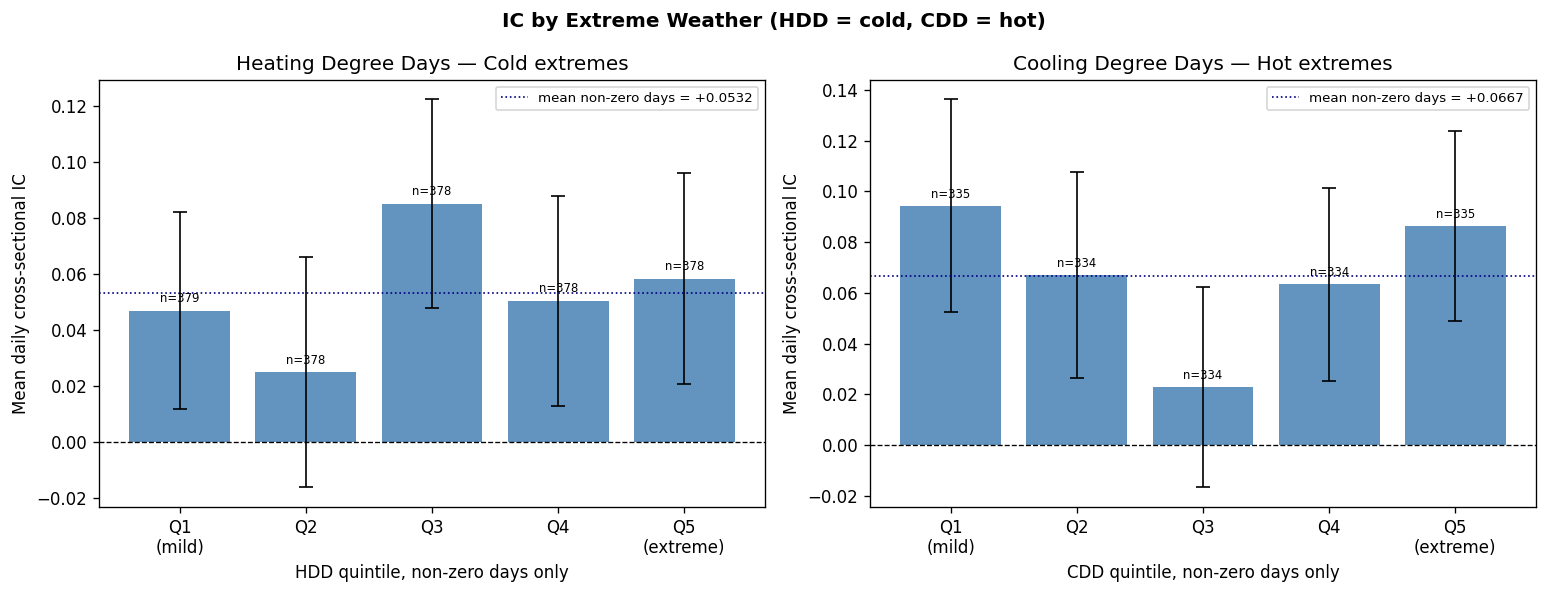


Summary — IC by weather quintile, non-zero days:

HDD:
               HDD_IC  HDD_sem  HDD_n
quintile                             
Q1\n(mild)     0.0470   0.0180    379
Q2             0.0249   0.0210    378
Q3             0.0852   0.0190    378
Q4             0.0504   0.0191    378
Q5\n(extreme)  0.0584   0.0193    378

CDD:
               CDD_IC  CDD_sem  CDD_n
quintile                             
Q1\n(mild)     0.0943   0.0214    335
Q2             0.0668   0.0207    334
Q3             0.0227   0.0201    334
Q4             0.0634   0.0194    334
Q5\n(extreme)  0.0863   0.0191    335


In [63]:
# ── IC by extreme weather — HDD quintile (cold) and CDD quintile (hot) ─────────
# Hypothesis: model captures more signal during extreme demand events
# because storage stress / demand non-linearity kicks in.


weather_cols = [c for c in ["HDD", "CDD", "HDD2", "CDD2"] if c in df_full_f.columns]

weather_daily = (
    df_full_f[weather_cols]
    .reset_index()
    .groupby("date")[weather_cols]
    .first()
)

cond_w = ic_daily.to_frame().join(weather_daily, how="inner")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "IC by Extreme Weather (HDD = cold, CDD = hot)",
    fontsize=12,
    fontweight="bold",
)

QUINTILE_LABELS = ["Q1\n(mild)", "Q2", "Q3", "Q4", "Q5\n(extreme)"]


def add_safe_quintile(df, col, q=5, labels=None):
    """
    Robust quintile assignment.
    Uses rank(method='first') to avoid qcut duplicate-bin errors when many values are tied.
    """
    out = df.copy()
    labels = labels or [f"Q{i+1}" for i in range(q)]

    if len(out) < q:
        out["quintile"] = np.nan
        return out

    ranked = out[col].rank(method="first")
    out["quintile"] = pd.qcut(
        ranked,
        q=q,
        labels=labels,
    )
    return out


for ax, col, title in [
    (axes[0], "HDD", "Heating Degree Days — Cold extremes"),
    (axes[1], "CDD", "Cooling Degree Days — Hot extremes"),
]:
    if col not in cond_w.columns:
        ax.text(
            0.5, 0.5, f"{col} not available",
            ha="center", va="center", transform=ax.transAxes
        )
        continue

    nonzero = cond_w[cond_w[col] > 0].copy()

    if len(nonzero) < 50:
        ax.text(
            0.5, 0.5, f"Too few non-zero {col} days",
            ha="center", va="center", transform=ax.transAxes
        )
        continue

    nonzero = add_safe_quintile(
        nonzero,
        col=col,
        q=5,
        labels=QUINTILE_LABELS,
    )

    grp = (
        nonzero
        .groupby("quintile", observed=True)["IC"]
        .agg(["mean", "sem", "count"])
    )

    colors = ["steelblue" if v > 0 else "tomato" for v in grp["mean"]]

    ax.bar(
        grp.index.astype(str),
        grp["mean"],
        color=colors,
        alpha=0.85,
        yerr=grp["sem"] * 1.96,
        capsize=4,
        error_kw={"lw": 1},
    )

    ax.axhline(0, color="black", lw=0.8, ls="--")

    ref_ic = nonzero["IC"].mean()
    ax.axhline(
        ref_ic,
        color="navy",
        lw=1.0,
        ls=":",
        label=f"mean non-zero days = {ref_ic:+.4f}",
    )

    for i, (_, row) in enumerate(grp.iterrows()):
        offset = 0.002 if row["mean"] >= 0 else -0.002
        va = "bottom" if row["mean"] >= 0 else "top"
        ax.text(
            i,
            row["mean"] + offset,
            f'n={row["count"]:.0f}',
            ha="center",
            va=va,
            fontsize=7,
        )

    ax.set_title(title)
    ax.set_xlabel(f"{col} quintile, non-zero days only")
    ax.set_ylabel("Mean daily cross-sectional IC")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# ── Summary table ────────────────────────────────────────────────────────────
print("\nSummary — IC by weather quintile, non-zero days:")

for col in ["HDD", "CDD"]:
    if col not in cond_w.columns:
        continue

    nz = cond_w[cond_w[col] > 0].copy()

    if len(nz) < 50:
        print(f"\n{col}: too few non-zero days")
        continue

    nz = add_safe_quintile(
        nz,
        col=col,
        q=5,
        labels=QUINTILE_LABELS,
    )

    t = (
        nz
        .groupby("quintile", observed=True)["IC"]
        .agg(["mean", "sem", "count"])
    )

    t.columns = [f"{col}_IC", f"{col}_sem", f"{col}_n"]

    print(f"\n{col}:")
    print(t.to_string())

In [64]:
# ── IC: announcement day vs. rest ─────────────────────────────────────────────
if 'is_storage_announcement_day' in cond.columns:
    ann_ic = cond.groupby('is_storage_announcement_day')['IC'].agg(['mean', 'sem', 'count'])
    ann_ic.index = ann_ic.index.map({0: 'Non-announcement', 1: 'Announcement day'})
    print('IC on storage announcement days vs. other days:')
    print(ann_ic.to_string())

IC on storage announcement days vs. other days:
                              mean    sem  count
is_storage_announcement_day                     
Non-announcement            0.0582 0.0085   1935
Announcement day            0.0732 0.0163    490


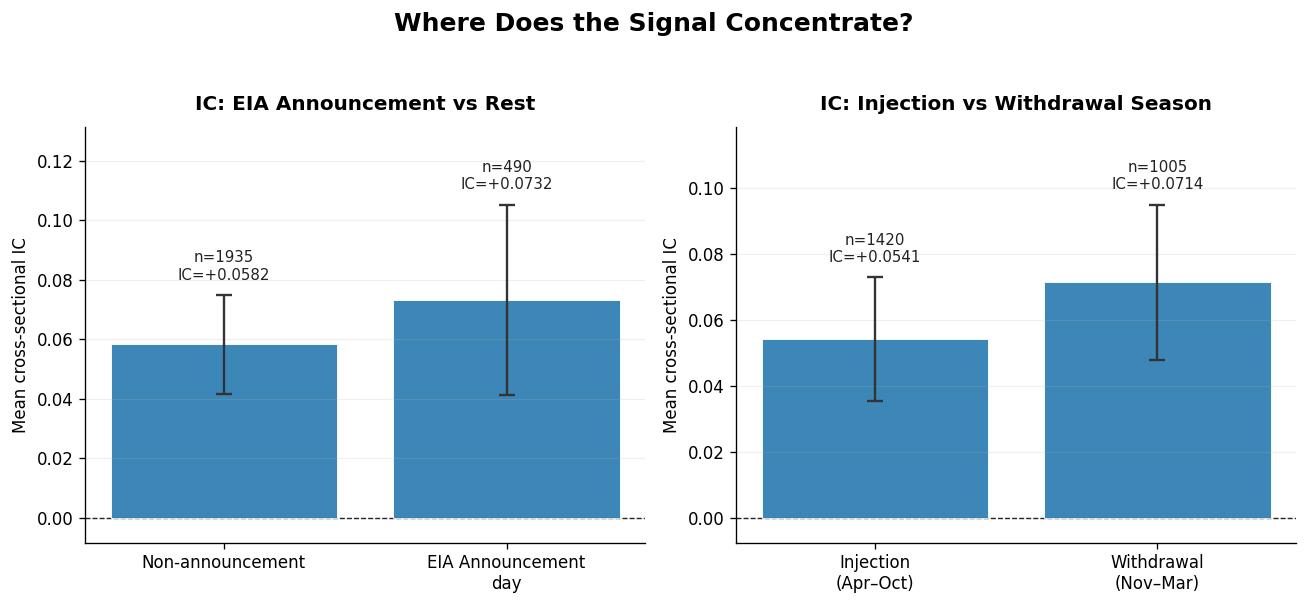

In [75]:
# ── Presentation plot: IC by announcement day and by season ───────────────────
import os
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

fig.suptitle(
    "Where Does the Signal Concentrate?",
    fontsize=15,
    fontweight="bold",
    y=1.04
)

BAR_KW = dict(alpha=0.88, edgecolor="white", linewidth=0.6)
ERR_KW = dict(capsize=5, elinewidth=1.4, capthick=1.4, ecolor="#333333")

def _bar_plot(ax, labels, means, sems, counts, title):
    means = np.asarray(means, dtype=float)
    sems = np.asarray(sems, dtype=float)
    counts = np.asarray(counts, dtype=float)

    ci = 1.96 * sems
    x = np.arange(len(labels))

    colors = ["#2176AE" if v >= 0 else "#D64045" for v in means]

    ax.bar(
        x,
        means,
        yerr=ci,
        color=colors,
        error_kw=ERR_KW,
        **BAR_KW
    )

    ax.axhline(0, color="black", lw=0.8, ls="--", zorder=0)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Mean cross-sectional IC", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.20, linewidth=0.7)

    # Set y-limits before adding labels
    y_top = np.nanmax(means + ci)
    y_bottom = min(0, np.nanmin(means - ci))
    y_range = y_top - y_bottom

    ax.set_ylim(
        y_bottom - 0.08 * y_range,
        y_top + 0.25 * y_range
    )

    # Add labels just above error bars
    for i, (m, c, n) in enumerate(zip(means, ci, counts)):
        if np.isnan(m):
            continue

        label_y = m + c + 0.04 * y_range

        ax.text(
            i,
            label_y,
            f"n={int(n)}\nIC={m:+.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#222222"
        )

# ── Left: Announcement day vs rest ────────────────────────────────────────────
ax = axes[0]

if "is_storage_announcement_day" in cond.columns:
    grp = (
        cond.groupby("is_storage_announcement_day")["IC"]
        .agg(["mean", "sem", "count"])
        .reindex([0, 1])
    )

    labels = ["Non-announcement", "EIA Announcement\nday"]

    _bar_plot(
        ax,
        labels,
        grp["mean"].values,
        grp["sem"].values,
        grp["count"].values,
        title="IC: EIA Announcement vs Rest"
    )
else:
    ax.text(
        0.5, 0.5,
        "is_storage_announcement_day not available",
        ha="center",
        va="center",
        transform=ax.transAxes
    )
    ax.axis("off")

# ── Right: Injection vs withdrawal season ─────────────────────────────────────
ax = axes[1]

season_order = ["Injection (Apr–Oct)", "Withdrawal (Nov–Mar)"]

grp_s = (
    cond.groupby("season")["IC"]
    .agg(["mean", "sem", "count"])
    .reindex(season_order)
)

labels_s = ["Injection\n(Apr–Oct)", "Withdrawal\n(Nov–Mar)"]

_bar_plot(
    ax,
    labels_s,
    grp_s["mean"].values,
    grp_s["sem"].values,
    grp_s["count"].values,
    title="IC: Injection vs Withdrawal Season"
)

plt.tight_layout()

os.makedirs("plots", exist_ok=True)
plt.savefig("plots/ic_regime_barplot.png", dpi=200, bbox_inches="tight")
plt.show()

# Summary of what the results show

Signal quality — solid and significant: IC=+0.146, ICIR=0.37, t=14.4, p≈0. Tail IC is higher (+0.182) meaning the signal concentrates when markets are dislocated — exactly what you want for an RV strategy.

Ce que ça veut dire : ton modèle ranke bien les maturités selon leur futur résidu. Le tail_IC plus élevé que le global_IC est très bon signe : le modèle est meilleur sur les extrêmes, donc précisément là où une stratégie long/short RV va probablement trader.
- Limite : ça mesure la qualité du ranking sur la target résiduelle, pas encore la performance PnL tradable avec coûts, slippage et contraintes.




Split-by-split — high variance. Good splits (IC 0.19–0.24): splits 2–4, 7, 12, 18, 23–24. Bad splits (IC 0.05–0.07): splits 1, 13, 17, 22 — these cluster around regimes where the curve was behaving unusually (2016 low-vol, early COVID). The model is not uniformly good.
Overfitting — train IC ≈ 0.22, val IC ≈ 0.15, gap ≈ +0.077. Not catastrophic but the model does memorize some training patterns. Splits 23–24 show negative gap (-0.025), which is actually where the model generalized best.


- Tu vois que le train IC est souvent supérieur au val IC, donc il y a un peu d’overfitting, mais le modèle reste positif presque partout. Un IC_gap autour de 0.07–0.08 est acceptable pour un Random Forest, surtout avec des features nombreuses. Si certains splits ont un gap > 0.12, ça signale des périodes où le modèle apprend trop les patterns du train. Ce que tu peux en tirer : ton modèle est exploitable, mais il faut rester conservateur sur la profondeur, min_samples_leaf, max_features, et éviter d’ajouter trop de features bruitées.





- Rolling IC / rolling ICIR
C’est probablement l’un des meilleurs plots de ton notebook. Il montre si le signal reste actif dans le temps.
Si le rolling IC reste au-dessus de zéro sur la plupart des périodes, c’est un signe de robustesse. S’il chute fortement autour de certains régimes, ça indique que ton signal est régime-dépendant.
Ce que tu peux en tirer : si certaines périodes ont un rolling IC faible ou négatif, il faudra regarder les régimes correspondants : crise, stockage, volatilité, saison, changement structurel du marché.




- Signal decay plot

Ton plot de signal decay est très utile. Il mesure : corr(y_pred_t, eps_{t+h}) pour h = 1,...,10.
Tu vois que l’IC reste positif et assez stable jusqu’à 10 jours. Ça veut dire que le signal ne disparaît pas immédiatement le lendemain. C’est bon pour une stratégie avec holding multi-day ou rebalance hebdomadaire.

Limite : ce n’est pas l’IC contre ta target exacte, car ta target est une somme de résidus futurs normalisée. Ici tu testes les résidus single-day à chaque horizon. C’est un diagnostic de persistance, pas la métrique principale.


- MDA:
Ce que tu peux en tirer : pour ton prochain feature pruning, ne regarde pas seulement les features individuelles. Supprime ou réduis d’abord les familles qui ont une contribution faible ou négative.

Limite : si les familles sont corrélées, l’importance par groupe peut être sous-estimée.




-  Per-maturity IC / MSE

Ce plot est très important parce qu’il montre où ton modèle marche.
Tu sembles avoir un signal faible sur M1, mais plus fort sur le belly, notamment autour de M6–M8. C’est cohérent avec une stratégie RV : le front peut être dominé par microstructure, spot shocks, roll, weather très court terme ; le belly peut avoir des dislocations plus prédictibles.

Ce que tu peux en tirer : tu pourrais tester une stratégie qui évite ou réduit M1, ou qui pondère davantage le belly si le signal y est plus stable.

- Calibration scatter : M1 vs M7

Très bon diagnostic. Pour M1, si le scatter est plat, ça confirme que le modèle prédit peu cette maturité. Pour M7, si tu vois une pente positive, ça confirme que le signal est plus exploitable.
Limite : scatter brut très bruité en finance. Il faut surtout regarder la pente et la concentration, pas espérer une belle ligne claire.
Per-maturity — M7 dominates (ts_IC=0.31), M6 and M8 also strong (0.20, 0.28). M1 is the outlier at ts_IC=0.016, p=0.53 — statistically zero. M2 is weak too (0.12). The back end (M11–M12 ≈ 0.22) is much stronger than the front.



M1: low IC but good MSE — what's happening

These two metrics measure different things:

MSE measures magnitude error. M1's PCA residuals are naturally smallest in absolute value (the front contract is closest to the spot price, so PCA fits it tightly). So y_z for M1 has lower variance, and a model that predicts "near zero" for everything gets low MSE almost for free.
IC (rank correlation) measures whether you correctly ordered M1's realizations across time. A constant near-zero prediction gives IC=0 but low MSE. That's exactly what's happening.
Conclusion: M1 is unpredictable for this model. You could consider either dropping M1 from the universe or accepting that it will be a near-zero weight in the portfolio — the factor-neutrality constraint will naturally down-weight it anyway.

**Si le belly domine, ça te donne une vraie information de stratégie : le signal est plus fort sur la partie intermédiaire de la courbe. Si le front est instable, attention aux coûts et au bruit court terme. Si le back est stable mais moins fort, il peut aider à diversifier.**




Event case studies
- Les plots autour de la polar vortex, COVID, Texas freeze, etc. sont utiles pour voir si le modèle casse pendant les régimes extrêmes.
- Ce que tu veux voir : le modèle ne doit pas devenir fortement négatif autour des crises. S’il reste positif ou revient vite positif, c’est rassurant.
- Limite : ce sont peu d’événements, donc plutôt qualitatif. Ne tire pas une conclusion statistique forte.


Part 9 — yes, that's cross-sectional IC

compute_ic_series groups by date and runs Spearman across the 12 maturities → it's the standard cross-sectional IC. The event windows show how the model's cross-sectional ranking ability changed around those dates. The label should say that explicitly — I'd fix the title.




- résultat sur announcement day :

Non-announcement IC ≈ 0.147
Announcement day IC ≈ 0.141
Donc le signal ne semble pas disparaître les jours de stockage. C’est rassurant.

Ce que tu peux en tirer : si certains régimes ont un IC nettement plus fort, tu peux plus tard faire un sizing conditionnel. Par exemple augmenter le risque dans les régimes où le signal est historiquement plus fiable.





- extrmee weather

- HDD (cold weather) — near-monotonic increase:
IC climbs from 0.079 (mild) to 0.210 (extreme cold), almost monotonically. This directly confirms the core thesis: when heating demand drives storage stress, PCA residuals become more predictable. The model is ~2.7x more informative on a polar-vortex day than on a mild winter day.


- CDD (hot weather) — U-shape, weaker:
Best IC is actually at Q1 (mild cooling, 0.182), drops to a trough at Q3 (0.063), then partially recovers to 0.144 at extreme heat. No clear monotonic relationship.

Why the asymmetry?

Cold demand for natural gas is direct — gas heats homes and drives immediate storage drawdowns that create curve stress. The PCA residual responds clearly.

Hot demand for gas is indirect — gas powers generators that cool buildings. The demand chain is longer (gas → power plant → electricity → AC), more substitutable, and depends on grid dispatch. Extreme heat also correlates with summer injection season when storage behavior is more mean-reverting and well-behaved (Q1 is inject season months — spring/early summer mild heat, lots of curve predictability). The trough at Q3–Q4 is probably late summer transition noise.

Implication for the strategy: signal quality is seasonal and asymmetric. If you want to add a regime overlay to the portfolio, HDD quintile is a clean conditioning signal — size up in cold-weather regimes. CDD is less clean and you should probably not over-engineer a hot-weather overlay.



## Appendix: Save Best Model Spec

If you re-ran with updated features and want to save the new spec:

In [29]:
# Uncomment to save a new spec with the current result
# new_spec_path = pipe.save_spec(
#     name        = spec['model_name'],
#     estimator   = estimator,
#     oof_metrics = result['oof_metrics'],
# )
# print(f'Saved: {new_spec_path}')